# Exploración de datos

### 1. Contexto y objetivo
El objetivo de este proyecto es analizar la producción de petróleo de pozos no convencionales de Argentina y explorar si las características de los pozos y su historial de producción permiten predecir su comportamiento productivo futuro.

La pregunta principal que buscamos responder es:

> **Dadas las características de un pozo y su historial de producción, ¿cuánto petróleo esperamos que produzca el próximo mes?**

A partir de esta pregunta se plantean tres enfoques de Machine Learning:

- **Regresión:** predecir la cantidad de petróleo que producirá un pozo durante el próximo mes.
- **Clasificación:** categorizar la producción futura del pozo en diferentes niveles de producción.
- **Clustering:** identificar grupos de pozos con características y comportamientos productivos similares.

En esta primera etapa del proyecto realizaremos una exploración de los datos disponibles, buscando comprender su estructura, calidad, variables relevantes y relaciones entre las diferentes fuentes de información.

### Importación de librerías

Para realizar el análisis exploratorio utilizaremos principalmente **Pandas**, **NumPy** y **Matplotlib**.

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Indicamos que se visualicen todas las columnas del dataframe
pd.set_option("display.max_columns", None)

### Carga de los datasets

Para el análisis utilizaremos tres fuentes principales de información:

1. **Producción no convencional:** contiene registros mensuales de producción de petróleo, gas, agua y otras variables asociadas a los pozos no convencionales.
2. **Características de los pozos:** contiene información descriptiva de los pozos, como profundidad, formación, cuenca, tipo de recurso y tipo de extracción.
3. **Fracturación:** contiene información relacionada con las operaciones de fracturación de los pozos, incluyendo cantidad de fracturas, longitud de la rama horizontal, arena y agua utilizadas, entre otras variables.

Los archivos originales se mantienen sin modificar dentro de `data/raw/`.

In [118]:
produccion = pd.read_csv(
    "../data/raw/produccin-de-pozos-de-gas-y-petrleo-no-convencional.csv"
)

pozos = pd.read_csv(
    "../data/raw/capitulo-iv-pozos.csv"
)

fracturacion = pd.read_csv(
    "../data/raw/datos-de-fractura-de-pozos-de-hidrocarburos-adjunto-iv-actualizacin-diaria.csv"
)

### 2. Inspección inicial de los datasets

En esta primera etapa queremos conocer la estructura general de los datasets y verificar que los archivos hayan sido importados correctamente.

Antes de realizar transformaciones o eliminar datos, analizaremos:

- la cantidad de filas y columnas de cada dataset;
- los nombres de las variables disponibles;
- los tipos de datos;
- una muestra de los registros;
- la presencia de valores nulos;
- la existencia de registros duplicados.

Esta inspección inicial nos permitirá comprender qué información contiene cada fuente y detectar posibles problemas de calidad que deberán ser considerados durante las etapas posteriores del análisis.

> **Importante:** en esta etapa no eliminaremos datos automáticamente. Primero analizaremos qué representan y si los valores faltantes, ceros o duplicados tienen un significado dentro del problema.

#### 2.1 Dimensiones de los datasets

Comenzamos revisando las dimensiones de cada dataset.

El atributo `shape` de Pandas devuelve una tupla con la siguiente estructura:

```text
(filas, columnas)

In [119]:
resumen_dimensiones = pd.DataFrame({
    "Dataset": [
        "Producción no convencional",
        "Pozos",
        "Fracturación"
    ],
    "Filas": [
        produccion.shape[0],
        pozos.shape[0],
        fracturacion.shape[0]
    ],
    "Columnas": [
        produccion.shape[1],
        pozos.shape[1],
        fracturacion.shape[1]
    ]
})

display(resumen_dimensiones)

,Dataset,Filas,Columnas
0,Producción no convencional,421046,40
1,Pozos,85611,26
2,Fracturación,4890,30


#### 2.2. Nombres de las variables

Una vez conocidas las dimensiones de los datasets, analizamos las variables disponibles en cada fuente.

Conocer los nombres de las columnas nos permite identificar qué tipo de información contiene cada dataset y comenzar a determinar qué variables podrían ser relevantes para nuestro problema de predicción.

En particular, nos interesa identificar:

- variables que describan las características de los pozos;
- variables relacionadas con la producción;
- variables temporales, como año y mes;
- variables relacionadas con la fracturación;
- identificadores que permitan relacionar los diferentes datasets.

En esta etapa solamente identificaremos las variables disponibles.

In [120]:
columnas_datasets = pd.DataFrame({
    "Producción": pd.Series(produccion.columns),
    "Pozos": pd.Series(pozos.columns),
    "Fracturación": pd.Series(fracturacion.columns)
})

display(columnas_datasets)

,Producción,Pozos,Fracturación
0,idempresa,sigla,id_base_fractura_adjiv
1,anio,idpozo,idpozo
2,mes,area,sigla
3,idpozo,cod_area,cuenca
4,prod_pet,empresa,areapermisoconcesion
5,prod_gas,yacimiento,yacimiento
6,prod_agua,cod_yacimiento,formacion_productiva
7,iny_agua,formacion,tipo_reservorio
8,iny_gas,cuenca,subtipo_reservorio
9,iny_co2,provincia,longitud_rama_horizontal_m


##### 2.2.1. Diccionario de datos de las variables principales

Luego de identificar las columnas disponibles, se presenta una descripción general de las variables más relevantes de cada dataset.

##### Dataset de producción

| Variable | Descripción |
|---|---|
| `idpozo` | Identificador único del pozo. Permite relacionar la información de producción con los datasets de pozos y fracturación. |
| `anio` | Año correspondiente al período de producción registrado. |
| `mes` | Mes correspondiente al período de producción registrado. |
| `fecha_data` | Fecha asociada al período de producción. Su año y mes coinciden con las variables `anio` y `mes`. |
| `prod_pet` | Producción de petróleo registrada para el pozo durante el período. Es la principal variable objetivo del proyecto. |
| `prod_gas` | Producción de gas registrada para el pozo durante el período. |
| `prod_agua` | Producción de agua registrada para el pozo durante el período. |
| `iny_agua` | Volumen de agua inyectada durante el período. |
| `iny_gas` | Volumen de gas inyectado durante el período. |
| `tef` | Tiempo efectivo de producción del pozo durante el mes, expresado aproximadamente en días. |
| `tipoestado` | Estado operativo informado para el pozo durante el período, por ejemplo, extracción efectiva o pozo parado. |
| `tipopozo` | Tipo de pozo según su actividad o fluido principal, como petrolífero, gasífero o inyector. |
| `cuenca` | Cuenca geológica o región productiva a la que pertenece el pozo. |
| `formacion` | Formación geológica asociada al pozo. |
| `profundidad` | Profundidad informada para el pozo, presumiblemente expresada en metros. |
| `coordenadax` | Coordenada geográfica del pozo, interpretada como longitud. |
| `coordenaday` | Coordenada geográfica del pozo, interpretada como latitud. |
| `fechaingreso` | Fecha y hora en que el registro fue ingresado o cargado en el sistema. No necesariamente representa el período de producción. |

##### Dataset de características de los pozos

| Variable | Descripción |
|---|---|
| `idpozo` | Identificador del pozo utilizado para relacionar esta fuente con los demás datasets. |
| `cuenca` | Cuenca geológica o región donde se encuentra ubicado el pozo. |
| `formacion` | Formación geológica asociada al pozo. |
| `tipo_recurso` | Tipo de recurso del pozo, por ejemplo, convencional o no convencional. |
| `tipopozo` | Clasificación del pozo según el tipo de producción o función que cumple. |
| `profundidad` | Profundidad total informada del pozo, presumiblemente en metros. |
| `cota` | Elevación o altura de referencia del terreno donde se encuentra el pozo. |
| `empresa` | Empresa operadora o responsable del pozo. |
| `gasplus` | Indicador que señala si el pozo pertenece al programa Gas Plus. |
| `adjiv_fecha_inicio_perf` | Fecha de inicio de la perforación. |
| `adjiv_fecha_fin_perf` | Fecha de finalización de la perforación. |
| `adjiv_fecha_inicio_term` | Fecha de inicio de la terminación del pozo. |
| `adjiv_fecha_fin_term` | Fecha de finalización de la terminación del pozo. |

##### Dataset de fracturación

| Variable | Descripción |
|---|---|
| `idpozo` | Identificador del pozo al que corresponde el registro de fracturación. |
| `anio` | Año asociado al registro o a la información de fracturación. |
| `mes` | Mes asociado al registro o a la información de fracturación. |
| `fecha_inicio_fractura` | Fecha de inicio de la operación de fracturación. |
| `fecha_fin_fractura` | Fecha de finalización de la operación de fracturación. |
| `formacion_productiva` | Formación geológica productiva asociada a la operación. |
| `longitud_rama_horizontal_m` | Longitud de la rama horizontal del pozo, expresada en metros. Un valor igual a cero puede corresponder a pozos verticales. |
| `cantidad_fracturas` | Cantidad de fracturas o etapas de fracturación realizadas. |
| `arena_bombeada_nacional_tn` | Cantidad de arena nacional utilizada durante la fracturación, expresada en toneladas. |
| `arena_bombeada_importada_tn` | Cantidad de arena importada utilizada durante la fracturación, expresada en toneladas. |
| `agua_inyectada_m3` | Volumen de agua utilizado o inyectado durante la operación, expresado en metros cúbicos. |
| `presion_maxima_psi` | Presión máxima alcanzada durante la fracturación, expresada en psi. |
| `potencia_equipos_fractura_hp` | Potencia de los equipos utilizados durante la fracturación, expresada en hp. |
| `tipo_reservorio` | Tipo de reservorio asociado al pozo o a la operación. |
| `subtipo_reservorio` | Clasificación más específica del tipo de reservorio. |


### 2.3. Primer vistazo a los registros

Los nombres de las columnas nos permiten conocer qué variables están disponibles, pero todavía no muestran cómo están representados los datos.

Para obtener una primera visión del contenido de cada dataset utilizaremos `head()`, que permite visualizar los primeros registros.

Esta inspección nos ayuda a:

- comprobar que los datos fueron cargados correctamente;
- observar el formato de los valores;
- identificar posibles inconsistencias evidentes;
- relacionar los nombres de las variables con los valores que contienen.

La visualización de los primeros registros no implica que estos sean representativos de todo el dataset. Se utiliza únicamente como una primera inspección.

In [121]:
print("Primeros registros del dataset de producción:")
display(produccion.head())

Primeros registros del dataset de producción:


,idempresa,anio,mes,idpozo,prod_pet,prod_gas,prod_agua,iny_agua,iny_gas,iny_co2,iny_otro,tef,vida_util,tipoextraccion,tipoestado,tipopozo,observaciones,fechaingreso,rectificado,habilitado,idusuario,empresa,sigla,formprod,profundidad,formacion,idareapermisoconcesion,areapermisoconcesion,idareayacimiento,areayacimiento,cuenca,provincia,coordenadax,coordenaday,tipo_de_recurso,proyecto,clasificacion,subclasificacion,sub_tipo_recurso,fecha_data
0,YSUR,2015,1,132909,16.74,241.220,13.42,0.0,0.0,0.0,0.0,31.00,NaN,Plunger Lift,Extracción Efectiva,Gasífero,NaN,2015-02-26 13:35:35.533458,f,t,5,YSUR ENERGÍA ARGENTINA S.R.L.,AEA.NQ.RCo-1039,PREC,2678.0,precuyo,SDD,AL SUR DE LA DORSAL,RQC,RANQUIL CO,NEUQUINA,Neuquén,-69.202207,-39.081820,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2015-01-31
1,YSUR,2018,1,132488,0.00,171.937,0.00,0.0,0.0,0.0,0.0,30.73,NaN,Surgencia Natural,Extracción Efectiva,Gasífero,NaN,2018-02-10 08:37:14.717426,f,t,444,YSUR ENERGÍA ARGENTINA S.R.L.,AEA.RN.EFO-99(d),LAJA,3828.0,lajas,FEO,ESTACION FERNANDEZ ORO,Z155,ESTACION FERNANDEZ ORO,NEUQUINA,Rio Negro,-67.864960,-39.016722,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2018-01-31
2,YSUR,2017,1,134325,22.34,365.610,1.20,0.0,0.0,0.0,0.0,31.00,NaN,Plunger Lift,Extracción Efectiva,Gasífero,NaN,2017-02-16 13:45:37.233373,f,t,444,YSUR ENERGÍA ARGENTINA S.R.L.,APA.RN.EFO-117(d),LAJA,3793.0,lajas,FEO,ESTACION FERNANDEZ ORO,Z155,ESTACION FERNANDEZ ORO,NEUQUINA,Rio Negro,-67.849735,-39.020644,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2017-01-31
3,YSUR,2018,1,132487,0.00,514.696,17.00,0.0,0.0,0.0,0.0,29.90,NaN,Surgencia Natural,Extracción Efectiva,Gasífero,NaN,2018-02-10 08:37:14.717426,f,t,444,YSUR ENERGÍA ARGENTINA S.R.L.,APA.RN.EFO-139(d),FIMP,2707.0,formación improductiva,FEO,ESTACION FERNANDEZ ORO,Z155,ESTACION FERNANDEZ ORO,NEUQUINA,Rio Negro,-67.837875,-39.019313,NO CONVENCIONAL,Sin Proyecto,EXPLOTACION,DESARROLLO,TIGHT,2018-01-31
4,YSUR,2016,1,153522,234.87,1651.240,94.12,0.0,0.0,0.0,0.0,30.79,NaN,Surgencia Natural,Extracción Efectiva,Gasífero,NaN,2016-02-17 10:50:46.929347,f,t,5,YSUR ENERGÍA ARGENTINA S.R.L.,APA.RN.EFO-231(d),LAJA,3844.0,lajas,FEO,ESTACION FERNANDEZ ORO,Z155,ESTACION FERNANDEZ ORO,NEUQUINA,Rio Negro,-67.810843,-39.024083,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2016-01-31


In [122]:
print("Primeros registros del dataset de pozos:")
display(pozos.head())

Primeros registros del dataset de pozos:


,sigla,idpozo,area,cod_area,empresa,yacimiento,cod_yacimiento,formacion,cuenca,provincia,cota,profundidad,clasificacion,subclasificacion,tipo_recurso,sub_tipo_recurso,gasplus,tipopozo,tipoextraccion,tipoestado,adjiv_fecha_inicio_perf,adjiv_fecha_fin_perf,adjiv_fecha_inicio_term,adjiv_fecha_fin_term,geojson,geom
0,CH.CH.EaLE.x-1,212,ESTANCIA LA ESCONDIDA,ECH,COLHUE HUAPI S.A.,ESTANCIA LA ESCONDIDA,ELA,comodoro rivadavia,GOLFO SAN JORGE,Chubut,255.00,1702.0,EXPLORACION,EXPLORACION,CONVENCIONAL,No informado,no,Petrolífero,Bombeo Mecánico,Extracción Efectiva,1996-10-30,1996-11-13,1996-11-17,1996-12-07,"{""type"":""Point"",""coordinates"":[-68.28785299999...",0101000020E61000008D43FD2E6C1251C00E4B033FAACB...
1,CH.CH.EaLE.x-2,213,ESTANCIA LA ESCONDIDA,ECH,COLHUE HUAPI S.A.,ESTANCIA LA ESCONDIDA,ELA,comodoro rivadavia,GOLFO SAN JORGE,Chubut,251.00,1350.0,EXPLORACION,EXPLORACION,CONVENCIONAL,No informado,no,Inyección de Agua,Sin Sistema de Extracción,En Inyección Efectiva,1996-10-14,1996-11-13,1996-12-09,1996-12-17,"{""type"":""Point"",""coordinates"":[-68.29201899999...",0101000020E6100000E1B37570B01251C00BB5A679C7CB...
2,CH.CH.EaLE-3,214,ESTANCIA LA ESCONDIDA,ECH,COLHUE HUAPI S.A.,ESTANCIA LA ESCONDIDA,ELA,comodoro rivadavia,GOLFO SAN JORGE,Chubut,256.15,1350.0,EXPLOTACION,DESARROLLO,CONVENCIONAL,No informado,no,Petrolífero,Bombeo Mecánico,Extracción Efectiva,1997-01-30,1997-02-07,1997-03-02,1997-03-10,"{""type"":""Point"",""coordinates"":[-68.28387800000...",0101000020E61000007383A10E2B1251C082548A1D8DCB...
3,CH.CH.EaLE-4,215,ESTANCIA LA ESCONDIDA,ECH,COLHUE HUAPI S.A.,ESTANCIA LA ESCONDIDA,ELA,comodoro rivadavia,GOLFO SAN JORGE,Chubut,256.70,1351.0,EXPLOTACION,DESARROLLO,CONVENCIONAL,No informado,no,Petrolífero,Bombeo Mecánico,Extracción Efectiva,1997-01-13,1997-01-20,1997-01-23,1997-02-07,"{""type"":""Point"",""coordinates"":[-68.28948300000...",0101000020E6100000DF6FB4E3861251C0A148F7730ACC...
4,CH.CH.EaLE-5,216,ESTANCIA LA ESCONDIDA,ECH,COLHUE HUAPI S.A.,ESTANCIA LA ESCONDIDA,ELA,comodoro rivadavia,GOLFO SAN JORGE,Chubut,256.00,1350.0,EXPLOTACION,DESARROLLO,CONVENCIONAL,No informado,no,Petrolífero,Bombeo Mecánico,Extracción Efectiva,1997-02-16,1997-02-24,1997-03-10,1997-03-18,"{""type"":""Point"",""coordinates"":[-68.29447500000...",0101000020E6100000569FABADD81251C0B98D06F016CC...


In [123]:
print("Primeros registros del dataset de fracturación:")
display(fracturacion.head())

Primeros registros del dataset de fracturación:


,id_base_fractura_adjiv,idpozo,sigla,cuenca,areapermisoconcesion,yacimiento,formacion_productiva,tipo_reservorio,subtipo_reservorio,longitud_rama_horizontal_m,cantidad_fracturas,tipo_terminacion,arena_bombeada_nacional_tn,arena_bombeada_importada_tn,agua_inyectada_m3,co2_inyectado_m3,presion_maxima_psi,potencia_equipos_fractura_hp,fecha_inicio_fractura,fecha_fin_fractura,fecha_data,anio_if,mes_if,anio_ff,mes_ff,anio_carga,mes_carga,empresa_informante,mes,anio
0,30,159910,APS.Nq.ADC.xp-1033,NEUQUINA,AGUA DEL CAJON,AGUA DEL CAJON,los molles,NO CONVENCIONAL,SHALE,0.0,3,Punzado,0.000,0.000,2718.20,0.0,10190.0,10897.0,2019-04-20,2019-04-30,2019-06-14 17:13:03.68279,2019,4,2019,4,2019,6,CAPEX S.A.,4,2019
1,31,159910,APS.Nq.ADC.xp-1033,NEUQUINA,AGUA DEL CAJON,AGUA DEL CAJON,los molles,NO CONVENCIONAL,SHALE,0.0,1,Punzado,0.000,0.000,600.00,0.0,9250.0,10251.0,2018-11-02,2018-11-03,2019-06-14 17:14:19.179874,2018,11,2018,11,2019,6,CAPEX S.A.,11,2018
2,37,159219,YPF.Nq.AdlA-1001(h),NEUQUINA,AGUADA DE LA ARENA,AGUADA DE LA ARENA,vaca muerta,NO CONVENCIONAL,SHALE,1437.3,18,Tapón disparo,3761.370,536.850,25768.30,0.0,15000.0,32000.0,2017-11-19,2017-12-14,2019-06-27 13:46:21.14935,2017,11,2017,12,2019,6,YPF S.A.,11,2017
3,38,159220,YPF.Nq.AdlA-1002(h),NEUQUINA,AGUADA DE LA ARENA,AGUADA DE LA ARENA,vaca muerta,NO CONVENCIONAL,SHALE,1518.3,19,Tapón disparo,3903.705,558.225,27398.37,0.0,11348.0,32000.0,2017-11-21,2017-12-15,2019-06-27 13:46:21.14935,2017,11,2017,12,2019,6,YPF S.A.,11,2017
4,39,159221,YPF.Nq.AdlA-1003(h),NEUQUINA,AGUADA DE LA ARENA,AGUADA DE LA ARENA,vaca muerta,NO CONVENCIONAL,SHALE,1482.3,19,Tapón disparo,3949.020,569.925,27157.60,0.0,11076.0,32000.0,2017-11-18,2017-12-15,2019-06-27 13:46:21.14935,2017,11,2017,12,2019,6,YPF S.A.,11,2017


### 2.4. Tipos de datos

A continuación analizamos el tipo de dato asignado por Pandas a cada variable.

Los tipos de datos son importantes porque determinan qué operaciones podemos realizar sobre cada columna.

Por ejemplo:

- las variables numéricas pueden utilizarse para cálculos estadísticos;
- las variables de texto permiten agrupar o analizar categorías;
- las variables de fecha requieren un tratamiento específico para realizar análisis temporales.

Esta revisión también nos permite detectar columnas que eventualmente deberán ser transformadas antes del análisis o del entrenamiento de los modelos.

In [124]:
print("Tipos de datos - Producción:")
display(produccion.dtypes)

Tipos de datos - Producción:


idempresa                     str
anio                        int64
mes                         int64
idpozo                      int64
prod_pet                  float64
prod_gas                  float64
prod_agua                 float64
iny_agua                  float64
iny_gas                   float64
iny_co2                   float64
iny_otro                  float64
tef                       float64
vida_util                 float64
tipoextraccion                str
tipoestado                    str
tipopozo                      str
observaciones                 str
fechaingreso                  str
rectificado                   str
habilitado                    str
idusuario                   int64
empresa                       str
sigla                         str
formprod                      str
profundidad               float64
formacion                     str
idareapermisoconcesion        str
areapermisoconcesion          str
idareayacimiento              str
areayacimiento

In [125]:
print("Tipos de datos - Pozos:")
display(pozos.dtypes)

Tipos de datos - Pozos:


sigla                          str
idpozo                       int64
area                           str
cod_area                       str
empresa                        str
yacimiento                     str
cod_yacimiento                 str
formacion                      str
cuenca                         str
provincia                      str
cota                       float64
profundidad                float64
clasificacion                  str
subclasificacion               str
tipo_recurso                   str
sub_tipo_recurso               str
gasplus                        str
tipopozo                       str
tipoextraccion                 str
tipoestado                     str
adjiv_fecha_inicio_perf        str
adjiv_fecha_fin_perf           str
adjiv_fecha_inicio_term        str
adjiv_fecha_fin_term           str
geojson                        str
geom                           str
dtype: object

In [126]:
print("Tipos de datos - Fracturación:")
display(fracturacion.dtypes)

Tipos de datos - Fracturación:


id_base_fractura_adjiv            int64
idpozo                            int64
sigla                               str
cuenca                              str
areapermisoconcesion                str
yacimiento                          str
formacion_productiva                str
tipo_reservorio                     str
subtipo_reservorio                  str
longitud_rama_horizontal_m      float64
cantidad_fracturas                int64
tipo_terminacion                    str
arena_bombeada_nacional_tn      float64
arena_bombeada_importada_tn     float64
agua_inyectada_m3               float64
co2_inyectado_m3                float64
presion_maxima_psi              float64
potencia_equipos_fractura_hp    float64
fecha_inicio_fractura               str
fecha_fin_fractura                  str
fecha_data                          str
anio_if                           int64
mes_if                            int64
anio_ff                           int64
mes_ff                            int64


### 2.5. Información general de los datasets

Utilizamos el método `info()` para obtener un resumen general de cada DataFrame.

Esta función permite observar:

- cantidad de registros;
- cantidad de columnas;
- nombre de las variables;
- cantidad de valores no nulos;
- tipo de dato de cada variable;
- uso aproximado de memoria.

Esta información será útil para detectar variables con valores faltantes y posibles diferencias entre los tipos de datos esperados y los encontrados.

In [127]:
print("Resumen general - Producción:")
produccion.info()

Resumen general - Producción:


<class 'pandas.DataFrame'>
RangeIndex: 421046 entries, 0 to 421045
Data columns (total 40 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   idempresa               421046 non-null  str    
 1   anio                    421046 non-null  int64  
 2   mes                     421046 non-null  int64  
 3   idpozo                  421046 non-null  int64  
 4   prod_pet                421046 non-null  float64
 5   prod_gas                421046 non-null  float64
 6   prod_agua               421046 non-null  float64
 7   iny_agua                421046 non-null  float64
 8   iny_gas                 421046 non-null  float64
 9   iny_co2                 421046 non-null  float64
 10  iny_otro                421046 non-null  float64
 11  tef                     421046 non-null  float64
 12  vida_util               8964 non-null    float64
 13  tipoextraccion          420432 non-null  str    
 14  tipoestado              420432 

In [128]:
print("Resumen general - Pozos:")
pozos.info()

Resumen general - Pozos:
<class 'pandas.DataFrame'>
RangeIndex: 85611 entries, 0 to 85610
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   sigla                    85611 non-null  str    
 1   idpozo                   85611 non-null  int64  
 2   area                     85611 non-null  str    
 3   cod_area                 85611 non-null  str    
 4   empresa                  84647 non-null  str    
 5   yacimiento               85611 non-null  str    
 6   cod_yacimiento           85611 non-null  str    
 7   formacion                82796 non-null  str    
 8   cuenca                   85611 non-null  str    
 9   provincia                85611 non-null  str    
 10  cota                     85611 non-null  float64
 11  profundidad              85611 non-null  float64
 12  clasificacion            85611 non-null  str    
 13  subclasificacion         85611 non-null  str    
 14  tipo_rec

In [129]:
print("Resumen general - Fracturación:")
fracturacion.info()

Resumen general - Fracturación:
<class 'pandas.DataFrame'>
RangeIndex: 4890 entries, 0 to 4889
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id_base_fractura_adjiv        4890 non-null   int64  
 1   idpozo                        4890 non-null   int64  
 2   sigla                         4890 non-null   str    
 3   cuenca                        4890 non-null   str    
 4   areapermisoconcesion          4890 non-null   str    
 5   yacimiento                    4890 non-null   str    
 6   formacion_productiva          4890 non-null   str    
 7   tipo_reservorio               4855 non-null   str    
 8   subtipo_reservorio            3916 non-null   str    
 9   longitud_rama_horizontal_m    4890 non-null   float64
 10  cantidad_fracturas            4890 non-null   int64  
 11  tipo_terminacion              4890 non-null   str    
 12  arena_bombeada_nacional_tn    4890 non-nu

### 2.6. Análisis de valores faltantes

Los valores faltantes son registros en los que una variable no contiene información.

Su presencia no implica necesariamente un error en los datos. En algunos casos puede significar que una característica no fue informada, que no corresponde al registro o que la fuente original no disponía de ese dato.

Por este motivo, en esta etapa no eliminaremos automáticamente las filas o columnas con valores faltantes. Primero identificaremos su cantidad y proporción para evaluar posteriormente cómo tratarlos.

Calcularemos:

- cantidad de valores faltantes por variable;
- porcentaje de valores faltantes respecto del total de registros.

In [130]:
def resumen_nulos(df):
    resumen = pd.DataFrame({
        "Valores nulos": df.isnull().sum(),
        "Porcentaje nulos": df.isnull().mean() * 100
    })
    
    return resumen.sort_values(
        by="Porcentaje nulos",
        ascending=False
    )

In [131]:
print("Valores faltantes - Producción")
display(resumen_nulos(produccion))

Valores faltantes - Producción


,Valores nulos,Porcentaje nulos
vida_util,412082,97.871016
observaciones,397045,94.299673
clasificacion,922,0.218978
subclasificacion,922,0.218978
tipopozo,614,0.145827
tipoextraccion,614,0.145827
tipoestado,614,0.145827
sub_tipo_recurso,452,0.107352
iny_agua,0,0.000000
prod_agua,0,0.000000


In [132]:
print("Valores faltantes - Pozos")
display(resumen_nulos(pozos))

Valores faltantes - Pozos


,Valores nulos,Porcentaje nulos
adjiv_fecha_inicio_term,36487,42.619523
adjiv_fecha_fin_term,36486,42.618355
adjiv_fecha_fin_perf,34149,39.888566
adjiv_fecha_inicio_perf,34004,39.719195
formacion,2815,3.288129
empresa,964,1.126024
idpozo,0,0.000000
sigla,0,0.000000
cod_area,0,0.000000
area,0,0.000000


In [133]:
print("Valores faltantes - Fracturación")
display(resumen_nulos(fracturacion))

Valores faltantes - Fracturación


,Valores nulos,Porcentaje nulos
subtipo_reservorio,974,19.918200
potencia_equipos_fractura_hp,51,1.042945
tipo_reservorio,35,0.715746
sigla,0,0.000000
id_base_fractura_adjiv,0,0.000000
cuenca,0,0.000000
yacimiento,0,0.000000
areapermisoconcesion,0,0.000000
formacion_productiva,0,0.000000
longitud_rama_horizontal_m,0,0.000000


#### 2.6.1. Valores faltantes en el dataset de producción

El dataset de producción presenta una cobertura completa para las principales variables productivas.

En particular, las variables `prod_pet`, `prod_gas`, `prod_agua`, `idpozo`, `anio` y `mes` no presentan valores faltantes.

La variable `vida_util` presenta un porcentaje muy elevado de valores ausentes (97,87%), mientras que `observaciones` presenta un 94,30% de valores ausentes. Debido a esta baja cobertura, estas variables deberán analizarse antes de considerar su utilización en etapas posteriores.

El resto de las variables con valores faltantes presenta porcentajes inferiores al 0,25%, por lo que su impacto sobre el conjunto de datos es reducido.

Por el momento no se eliminarán estas variables ni se imputarán sus valores. Su tratamiento se definirá posteriormente en función de su utilidad para el análisis y los modelos.

#### 2.6.2. Valores faltantes en el dataset de pozos

En el dataset de características de los pozos se observa una cobertura completa en la mayoría de las variables.

Las principales ausencias se concentran en las variables relacionadas con las fechas de perforación y terminación:

- `adjiv_fecha_inicio_term`: 42,62% de valores faltantes.
- `adjiv_fecha_fin_term`: 42,62%.
- `adjiv_fecha_fin_perf`: 39,89%.
- `adjiv_fecha_inicio_perf`: 39,72%.

También se observan valores faltantes en `formacion` (3,29%) y `empresa` (1,13%).

Los valores faltantes en las fechas deberán analizarse considerando que no necesariamente representan un error: pueden corresponder a pozos para los cuales determinada información no fue registrada o no se encuentra disponible en la fuente.

Por lo tanto, estas variables no serán eliminadas automáticamente y su tratamiento se definirá según su utilización en el análisis posterior.

#### 2.6.3. Valores faltantes en el dataset de fracturación

El dataset de fracturación presenta una cobertura elevada en la mayoría de sus variables.

La principal excepción es `subtipo_reservorio`, que presenta un 19,92% de valores faltantes. También se observan valores ausentes en `potencia_equipos_fractura_hp` (1,04%) y `tipo_reservorio` (0,72%).

Las variables directamente relacionadas con las características de la fracturación, como `longitud_rama_horizontal_m`, `cantidad_fracturas`, `arena_bombeada_nacional_tn`, `arena_bombeada_importada_tn`, `agua_inyectada_m3` y `presion_maxima_psi`, no presentan valores faltantes.

Esto resulta especialmente relevante para nuestro análisis, ya que estas variables podrían utilizarse posteriormente para caracterizar los pozos y estudiar su relación con el comportamiento productivo.

#### 2.6.4. Conclusiones sobre los valores faltantes

El análisis muestra que los tres datasets presentan, en general, una alta cobertura de información.

Las principales situaciones detectadas son:

- En **producción**, `vida_util` y `observaciones` presentan una proporción muy elevada de valores faltantes, mientras que las variables productivas principales no presentan ausencias.
- En **pozos**, los valores faltantes se concentran principalmente en las fechas de perforación y terminación.
- En **fracturación**, `subtipo_reservorio` presenta la mayor proporción de valores faltantes, mientras que las principales variables cuantitativas relacionadas con la fracturación presentan información completa.

En consecuencia, no se realizará una eliminación general de valores faltantes. El tratamiento será definido posteriormente según el uso de cada variable y las necesidades de los modelos.

Además, se tendrá especial cuidado en diferenciar los valores faltantes (`NaN`) de los valores cero, ya que un cero puede representar una medición real de producción o de otra variable.

### 2.7. Análisis de registros duplicados

Antes de realizar transformaciones, verificaremos si existen registros duplicados en las diferentes fuentes de datos.

Es importante diferenciar entre un registro completamente duplicado y la repetición de un identificador como `idpozo`.

En el dataset de producción es esperable que un mismo `idpozo` aparezca varias veces, ya que cada registro representa la producción de un pozo en un determinado período.

Por lo tanto, la repetición de `idpozo` no será considerada por sí sola como un duplicado. Primero analizaremos los registros completamente repetidos y luego la cantidad de registros y períodos disponibles para cada pozo.

In [134]:
resumen_duplicados = pd.DataFrame({
    "Dataset": [
        "Producción no convencional",
        "Pozos",
        "Fracturación"
    ],
    "Registros duplicados": [
        produccion.duplicated().sum(),
        pozos.duplicated().sum(),
        fracturacion.duplicated().sum()
    ]
})

display(resumen_duplicados)

,Dataset,Registros duplicados
0,Producción no convencional,0
1,Pozos,0
2,Fracturación,0


#### Conclusiones sobre los registros duplicados

No se encontraron registros completamente duplicados en ninguno de los tres datasets analizados.

Por lo tanto, no es necesario realizar una eliminación de duplicados en esta etapa.

La repetición de `idpozo` se analizará posteriormente de acuerdo con la granularidad de cada dataset, ya que un mismo pozo puede estar asociado a múltiples registros correspondientes a distintos períodos de producción o eventos de fracturación.


### 2.8. Análisis de identificadores y granularidad

En esta etapa buscamos entender qué representa cada registro de los datasets y cómo se comporta el identificador `idpozo`.

Este identificador será importante más adelante, ya que nos permitirá relacionar la información de producción con las características de los pozos y los datos de fracturación.

Primero analizaremos cuántos pozos diferentes tenemos en cada dataset y si un mismo pozo aparece en más de un registro.


#### 2.8.1. Cantidad de registros y pozos únicos

In [135]:
resumen_idpozo = pd.DataFrame({
    "Dataset": [
        "Producción no convencional",
        "Pozos",
        "Fracturación"
    ],
    "Cantidad de registros": [
        len(produccion),
        len(pozos),
        len(fracturacion)
    ],
    "Pozos únicos": [
        produccion["idpozo"].nunique(),
        pozos["idpozo"].nunique(),
        fracturacion["idpozo"].nunique()
    ]
})

display(resumen_idpozo)

,Dataset,Cantidad de registros,Pozos únicos
0,Producción no convencional,421046,5089
1,Pozos,85611,85611
2,Fracturación,4890,4646


La cantidad de registros y de pozos únicos permite observar que los tres datasets tienen diferentes niveles de detalle.

En producción se cuenta con 421.046 registros correspondientes a 5.089 pozos, por lo que un mismo pozo aparece en varios registros.

En el dataset de pozos hay 85.611 registros y la misma cantidad de idpozo únicos, lo que indica que cada pozo aparece una sola vez.

En fracturación se tienen 4.890 registros correspondientes a 4.646 pozos, por lo que algunos pozos aparecen en más de un registro.

#### 2.8.2. Cantidad de registros de producción por pozo

In [136]:
registros_por_pozo = (
    produccion
    .groupby("idpozo")
    .size()
    .reset_index(name="cantidad_registros")
)

display(registros_por_pozo.head(10))

,idpozo,cantidad_registros
0,3640,246
1,8043,246
2,10073,247
3,11191,247
4,11641,246
5,11642,246
6,11643,246
7,34833,246
8,42900,247
9,42905,247


In [137]:
registros_por_pozo["cantidad_registros"].describe()

count    5089.000000
mean       82.736490
std        58.315107
min         1.000000
25%        31.000000
50%        81.000000
75%       126.000000
max       247.000000
Name: cantidad_registros, dtype: float64

Al analizar la cantidad de registros de producción por pozo se observa que la cantidad de períodos disponibles varía entre los diferentes pozos.

La cantidad de registros por pozo va desde 1 hasta 247, con una mediana de 81 registros.

Esto muestra que los pozos no tienen todos la misma cantidad de información histórica. Algunos cuentan con pocos registros, mientras que otros tienen información correspondiente a varios años.

Esta diferencia deberá tenerse en cuenta posteriormente al construir las variables relacionadas con el historial de producción.


#### 2.8.3. Unicidad de pozo, año y mes

In [138]:
duplicados_periodo = (
    produccion
    .duplicated(subset=["idpozo", "anio", "mes"])
    .sum()
)

print("Registros duplicados para un mismo pozo, año y mes:", duplicados_periodo)

Registros duplicados para un mismo pozo, año y mes: 0


No se encontraron registros duplicados para una misma combinación de `idpozo`, `anio` y `mes`.

Esto indica que, dentro del dataset de producción, cada pozo tiene como máximo un registro para cada período mensual.

Por lo tanto, podemos considerar que la granularidad de este dataset es **pozo-mes**: cada fila representa la información productiva de un pozo para un determinado año y mes.


#### 2.8.4. Unicidad de `idpozo` en el dataset de pozos

In [139]:
duplicados_idpozo_pozos = pozos["idpozo"].duplicated().sum()

print("Idpozo duplicados en el dataset de pozos:", duplicados_idpozo_pozos)

Idpozo duplicados en el dataset de pozos: 0


No se encontraron idpozo duplicados en el dataset de pozos.

Esto confirma que cada identificador aparece una sola vez, por lo que este dataset tiene una granularidad de pozo: cada fila contiene información asociada a un pozo.

#### 2.8.5. Registros de fracturación por pozo

In [140]:
registros_fracturacion_por_pozo = (
    fracturacion
    .groupby("idpozo")
    .size()
    .reset_index(name="cantidad_registros")
)

display(registros_fracturacion_por_pozo.head(10))

,idpozo,cantidad_registros
0,458,1
1,460,1
2,5984,1
3,5990,1
4,5993,1
5,5994,1
6,6002,1
7,6007,1
8,6013,1
9,6019,1


In [141]:
registros_fracturacion_por_pozo["cantidad_registros"].describe()

count    4646.000000
mean        1.052518
std         0.290201
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         6.000000
Name: cantidad_registros, dtype: float64

En el dataset de fracturación, la mayoría de los pozos tienen un solo registro. Sin embargo, algunos pozos presentan más de un registro, llegando hasta un máximo de 6 registros para un mismo `idpozo`.

Por lo tanto, a diferencia del dataset de pozos, no existe una relación de uno a uno entre `idpozo` y registro de fracturación.

Esta característica deberá tenerse en cuenta posteriormente al relacionar este dataset con los demás, para evitar generar registros duplicados o multiplicar filas de forma no intencional.


#### 2.8.6. Conclusiones sobre identificadores y granularidad

El análisis permitió identificar la granularidad de cada una de las fuentes de datos:

* **Producción:** cada registro corresponde a un pozo en un determinado año y mes. Un mismo `idpozo` puede tener múltiples registros a lo largo del tiempo.
* **Pozos:** cada `idpozo` aparece una sola vez, por lo que cada registro corresponde a un pozo.
* **Fracturación:** un pozo puede tener uno o varios registros asociados a la información de fracturación.

Además, no se encontraron registros repetidos para una misma combinación de `idpozo`, `anio` y `mes` en producción.

Esta diferencia de granularidad será importante al momento de relacionar los datasets, ya que no todas las fuentes tienen una relación uno a uno mediante `idpozo`.


### 2.9. Análisis temporal y fechas

Como el proyecto busca analizar la producción de petróleo a lo largo del tiempo, es necesario revisar las variables relacionadas con fechas y períodos.

En los datasets encontramos información temporal representada de diferentes formas, principalmente mediante las variables `anio` y `mes`, además de algunas fechas almacenadas como texto.

En esta etapa vamos a revisar estas variables, comprobar su formato y convertir a tipo fecha aquellas que sean necesarias para realizar análisis temporales posteriormente.


#### 2.9.1. Analizar las variables anio y mes

Primero se analizarán los valores disponibles en las variables anio y mes, verificando sus valores mínimos y máximos y la cantidad de valores distintos.

In [142]:
print("Valores de la variable 'anio':")
print("Mínimo:", produccion["anio"].min())
print("Máximo:", produccion["anio"].max())
print("Cantidad de años:", produccion["anio"].nunique())

print("\nValores de la variable 'mes':")
print("Mínimo:", produccion["mes"].min())
print("Máximo:", produccion["mes"].max())
print("Cantidad de meses:", produccion["mes"].nunique())

Valores de la variable 'anio':
Mínimo: 2006
Máximo: 2026
Cantidad de años: 21

Valores de la variable 'mes':
Mínimo: 1
Máximo: 12
Cantidad de meses: 12


#### 2.9.2. Analizar la cobertura mensual por año

Se calculará la cantidad de meses registrados para cada año. Esto permitirá identificar si existen años completos y si el último año disponible contiene información parcial.

In [143]:
meses_por_anio = (
    produccion
    .groupby("anio")["mes"]
    .nunique()
    .reset_index(name="cantidad_meses")
    .sort_values("anio")
)

display(meses_por_anio)

,anio,cantidad_meses
0,2006,12
1,2007,12
2,2008,12
3,2009,12
4,2010,12
5,2011,12
6,2012,12
7,2013,12
8,2014,12
9,2015,12


#### 2.9.3. Comprobar los meses registrados por año

Además de contar los meses, se comprobará cuáles son los meses concretamente registrados para cada año. De esta manera se podrá detectar si existen meses faltantes dentro de un año.

In [144]:
meses_por_anio = (
    produccion
    .groupby("anio")["mes"]
    .unique()
    .reset_index(name="meses")
    .sort_values("anio")
)

display(meses_por_anio)

,anio,meses
0,2006,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
1,2007,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
2,2008,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
3,2009,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
4,2010,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
5,2011,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
6,2012,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
7,2013,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
8,2014,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
9,2015,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"


#### 2.9.4. Comprobar las combinaciones año-mes

Finalmente, se verificará que las combinaciones de anio y mes sean válidas y que no existan registros correspondientes a meses fuera del rango esperado de 1 a 12.

In [145]:
registros_por_mes = (
    produccion
    .groupby(["anio", "mes"])
    .size()
    .reset_index(name="cantidad_registros")
    .sort_values(["anio", "mes"])
)

display(registros_por_mes)

,anio,mes,cantidad_registros
0,2006,1,195
1,2006,2,196
2,2006,3,197
3,2006,4,197
4,2006,5,197
...,...,...,...
242,2026,3,4851
243,2026,4,4903
244,2026,5,4969
245,2026,6,5015


#### 2.9.5. Conclusiones del análisis temporal

El análisis temporal permite determinar el período cubierto por el dataset y conocer si la información disponible es completa o parcial según el año.

La cobertura observada comprende desde 2006 hasta 2026. Los años 2006 a 2025 presentan información para los 12 meses, mientras que 2026 contiene información únicamente de enero a julio.

Por lo tanto, el año 2026 representa un período parcial y deberá tenerse en cuenta en los análisis temporales y, especialmente, en las etapas posteriores de construcción de variables y modelos predictivos.

La estructura de las variables anio y mes resulta adecuada para representar la periodicidad mensual de los registros. Posteriormente, estas variables podrán utilizarse para construir una variable temporal de tipo fecha que facilite los cálculos y análisis cronológicos.

### 3. Exploración de variables

La idea de esta sección es ver que contienen realmente los datos y qué comportamiento tienen sus variables.

Primero vamos a analizar las variables numéricas de nuestro dataset principal, que es produccion, porque es el dataset sobre el cual se construirá principalmente el análisis y posteriormente el modelo.

Dentro de esas variables nos interesa especialmente prod_pet, ya que representa la producción de petróleo y será nuestra variable objetivo para la etapa de regresión.

#### 3.1. Estadísticas descriptivas

Luego de revisar la estructura general de los datasets, analizamos el comportamiento de sus principales variables numéricas.

En particular, nos interesa conocer los valores mínimos y máximos, los valores centrales y la dispersión de las variables relacionadas con la producción, inyección y características de los pozos.

Este análisis permite detectar diferencias importantes entre las variables y obtener una primera aproximación a la distribución de los datos antes de realizar transformaciones y visualizaciones más específicas.

In [146]:
variables_numericas_produccion = [
    "prod_pet",
    "prod_gas",
    "prod_agua",
    "iny_agua",
    "iny_gas",
    "iny_co2",
    "iny_otro",
    "tef",
    "profundidad"
]

display(produccion[variables_numericas_produccion].describe().T)

,count,mean,std,min,25%,50%,75%,max
prod_pet,421046.0,333.686552,937.959525,-0.001,0.00,7.782565,122.291725,26593.261
prod_gas,421046.0,629.669808,1628.853199,-12.267,8.23,103.610000,449.915250,40086.800
prod_agua,421046.0,188.769196,625.446470,0.000,0.00,12.650000,86.480000,34792.950
iny_agua,421046.0,27.090517,891.482388,0.000,0.00,0.000000,0.000000,70278.850
iny_gas,421046.0,35.333080,8579.103467,0.000,0.00,0.000000,0.000000,3569000.000
iny_co2,421046.0,0.000000,0.000000,0.000,0.00,0.000000,0.000000,0.000
iny_otro,421046.0,0.000000,0.000000,0.000,0.00,0.000000,0.000000,0.000
tef,421046.0,21.964405,12.181074,0.000,14.63,29.190000,30.630000,79.340
profundidad,421046.0,3765.601546,6536.666596,0.000,2858.00,3272.000000,4700.000000,378939.000


#### 3.2. Análisis de variables categóricas

Además de las variables numéricas, el dataset contiene distintas variables categóricas que describen las características de los pozos y de su contexto de producción.

En esta etapa analizamos algunas de las variables categóricas más relevantes para conocer cómo se distribuyen los registros entre las distintas cuencas, formaciones y tipos de extracción.

Este análisis nos permite conocer mejor la composición de los datos y detectar categorías con pocos registros o diferencias importantes entre ellas.

In [147]:
print("Registros por cuenca:")
display(
    produccion["cuenca"]
    .value_counts()
    .rename("cantidad_registros")
    .to_frame()
)

Registros por cuenca:


,cantidad_registros
cuenca,
NEUQUINA,404037
AUSTRAL,16197
GOLFO SAN JORGE,627
NOROESTE,185


In [148]:
print("Registros por formación: ")
display(
    produccion["formacion"]
    .value_counts()
    .rename("cantidad_registros")
    .to_frame()
)

Registros por formación: 


,cantidad_registros
formacion,
vaca muerta,216445
lajas,77407
mulichinco,34749
los molles,28011
magallanes,15605
precuyo,14603
quintuco,10958
punta rosada,9577
agrio,5671


In [149]:
print("Registros por tipo de extracción: ")
display(
    produccion["tipoextraccion"]
    .value_counts()
    .rename("cantidad_registros")
    .to_frame()
)

Registros por tipo de extracción: 


,cantidad_registros
tipoextraccion,
Surgencia Natural,271205
Plunger Lift,68532
Bombeo Mecánico,46630
Sin Sistema de Extracción,18159
Gas Lift,15040
Bombeo Hidráulico,349
Electrosumergible,297
Otros Tipos de Extracción,104
Jet Pump,98


In [150]:
print("Registros por tipo de estado: ")
display(
    produccion["tipoestado"]
    .value_counts()
    .rename("cantidad_registros")
    .to_frame()
)

Registros por tipo de estado: 


,cantidad_registros
tipoestado,
Extracción Efectiva,348150
Parado Transitoriamente,26440
En Estudio,23861
Abandonado,3724
A Abandonar,3724
Otras Situación Inactivo,3252
En Reserva de Gas,3074
En Espera de Reparación,2685
Otras Situación Activo,2318


#### 3.3. Análisis de la producción de petróleo

Como el objetivo principal del proyecto es predecir la producción futura de petróleo, analizamos con mayor detalle la variable `prod_pet`.

En primer lugar, buscamos conocer cómo se distribuyen los registros según tengan o no producción de petróleo y qué proporción representan dentro del dataset.

Este análisis nos permite tener una primera aproximación al comportamiento de la variable que posteriormente utilizaremos como objetivo para el modelo de regresión.

##### 3.3.1. Estadísticas de `prod_pet`

Ya analizamos `prod_pet` junto con las demás variables numéricas. En este caso, la analizamos por separado porque representa la producción de petróleo y será la variable objetivo de nuestro problema de predicción.

Primero revisamos sus principales estadísticas descriptivas y luego analizamos cómo se distribuyen los registros según tengan producción igual a cero, mayor a cero o negativa.

Para comenzar, revisamos las principales estadísticas descriptivas de `prod_pet` para conocer sus valores centrales, dispersión y rango.

In [151]:
print("Estadísticas de producción de petróleo:")
display(produccion["prod_pet"].describe().T)

Estadísticas de producción de petróleo:


count    421046.000000
mean        333.686552
std         937.959525
min          -0.001000
25%           0.000000
50%           7.782565
75%         122.291725
max       26593.261000
Name: prod_pet, dtype: float64

A continuación, contamos cuántos registros presentan producción de petróleo igual a cero, mayor a cero o negativa. Esto nos permite conocer cómo se distribuyen los registros según su nivel de producción.

In [152]:
cantidad_cero = (produccion["prod_pet"] == 0).sum()
cantidad_positiva = (produccion["prod_pet"] > 0).sum()
cantidad_negativa = (produccion["prod_pet"] < 0).sum()

print("Registros con producción de petróleo igual a cero:", cantidad_cero)
print("Registros con producción de petróleo mayor a cero:", cantidad_positiva)
print("Registros con producción de petróleo negativa:", cantidad_negativa)

Registros con producción de petróleo igual a cero: 148360
Registros con producción de petróleo mayor a cero: 272685
Registros con producción de petróleo negativa: 1


Para complementar las cantidades anteriores, calculamos qué porcentaje representan respecto del total de registros.

In [153]:
total_registros = len(produccion)

porcentaje_cero = cantidad_cero / total_registros * 100
porcentaje_positiva = cantidad_positiva / total_registros * 100
porcentaje_negativa = cantidad_negativa / total_registros * 100

print(f"Producción igual a cero: {porcentaje_cero:.2f}%")
print(f"Producción mayor a cero: {porcentaje_positiva:.2f}%")
print(f"Producción negativa: {porcentaje_negativa:.2f}%")

Producción igual a cero: 35.24%
Producción mayor a cero: 64.76%
Producción negativa: 0.00%


A partir de este análisis observamos que el 64,76% de los registros presenta producción de petróleo mayor a cero, mientras que el 35,24% tiene una producción igual a cero.

También se identificó un único registro con un valor negativo de producción (`-0,001`), por lo que su proporción sobre el total es prácticamente nula. Este registro deberá revisarse antes de realizar las transformaciones y el entrenamiento de los modelos, para determinar si corresponde a un ajuste o particularidad del origen de los datos.

Por otro lado, la diferencia entre la media de producción (333,69) y la mediana (7,78) muestra que los valores de producción no se encuentran distribuidos de manera uniforme y que existen registros con valores considerablemente superiores al nivel habitual. Esto será importante de considerar en las siguientes etapas del análisis.

##### 3.3.2. Distribución de `prod_pet`

En el análisis anterior observamos que la media de producción es considerablemente mayor que la mediana y que existen valores de producción muy superiores al resto de los registros.

Para comprender mejor este comportamiento, analizamos cómo se distribuyen los valores de `prod_pet`, prestando especial atención a los valores de producción más bajos y a los valores elevados.

Para conocer con mayor detalle cómo se concentran los valores de producción, calculamos algunos percentiles de `prod_pet`. Esto nos permite observar qué valores no son superados por determinados porcentajes de los registros.

In [154]:
percentiles_prod_pet = produccion["prod_pet"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99, 1.00]
)

display(percentiles_prod_pet)

0.50        7.782565
0.75      122.291725
0.90      991.743000
0.95     2004.728000
0.99     4891.135300
1.00    26593.261000
Name: prod_pet, dtype: float64

Los percentiles muestran que la producción de petróleo se encuentra fuertemente concentrada en valores bajos. La mediana es de 7,78, mientras que el 75% de los registros presenta una producción de hasta 122,29.

A medida que avanzamos hacia los percentiles superiores, los valores aumentan considerablemente: el 90% de los registros se encuentra por debajo de 991,74 y el 99% por debajo de 4.891,14. Sin embargo, el valor máximo alcanza 26.593,26.

Estos resultados indican que la variable `prod_pet` presenta una distribución sesgada hacia la derecha, con una concentración de registros en valores bajos y una cola formada por valores de producción considerablemente mayores.

En la sección 6.1 observamos esta distribución de forma gráfica mediante histogramas.

#### 3.4. Relación entre producción y estado del pozo

Hasta el momento analizamos las variables de forma individual. En esta etapa comenzamos a estudiar la relación entre ellas, tomando como referencia la producción de petróleo.

Primero analizamos cómo se distribuye `prod_pet` según el estado informado para cada registro. Esto nos permite comparar los niveles de producción entre los distintos estados y entender mejor la presencia de registros con producción nula o baja.


In [155]:
resumen_produccion_estado = (
    produccion
    .groupby("tipoestado")["prod_pet"]
    .agg(
        cantidad_registros="count",
        promedio="mean",
        mediana="median",
        minimo="min",
        maximo="max"
    )
    .sort_values("cantidad_registros", ascending=False)
)

display(resumen_produccion_estado)

,cantidad_registros,promedio,mediana,minimo,maximo
tipoestado,,,,,
Extracción Efectiva,348150,399.987669,20.38,0.000,26593.261000
Parado Transitoriamente,26440,19.583350,0.00,0.000,7727.100000
En Estudio,23861,3.810864,0.00,-0.001,4245.405667
A Abandonar,3724,0.377167,0.00,0.000,1404.570000
Abandonado,3724,0.133939,0.00,0.000,380.320000
Otras Situación Inactivo,3252,27.497251,0.00,0.000,10261.700000
En Reserva de Gas,3074,3.453981,0.00,0.000,3153.820448
En Espera de Reparación,2685,0.203588,0.00,0.000,326.080000
Otras Situación Activo,2318,228.447469,0.00,0.000,12656.480000


Para complementar el resumen anterior, analizamos qué proporción de los registros de cada estado presenta producción de petróleo mayor que cero.

Esto permite diferenciar los estados en los que la producción es frecuente de aquellos en los que predominan registros con producción nula.


In [156]:
produccion_por_estado = (
    produccion
    .groupby("tipoestado")
    .agg(
        cantidad_registros=("prod_pet", "count"),
        registros_con_produccion=("prod_pet", lambda x: (x > 0).sum())
    )
)

produccion_por_estado["porcentaje_con_produccion"] = (
    produccion_por_estado["registros_con_produccion"]
    / produccion_por_estado["cantidad_registros"]
    * 100
)

produccion_por_estado = produccion_por_estado.sort_values(
    "cantidad_registros",
    ascending=False
)

display(produccion_por_estado)

,cantidad_registros,registros_con_produccion,porcentaje_con_produccion
tipoestado,,,
Extracción Efectiva,348150,269047,77.279046
Parado Transitoriamente,26440,2618,9.901664
En Estudio,23861,128,0.536440
A Abandonar,3724,1,0.026853
Abandonado,3724,3,0.080559
Otras Situación Inactivo,3252,43,1.322263
En Reserva de Gas,3074,8,0.260247
En Espera de Reparación,2685,4,0.148976
Otras Situación Activo,2318,812,35.030198


Los resultados muestran diferencias importantes entre los estados informados para los registros de producción.

`Extracción Efectiva` concentra la mayor cantidad de observaciones, con 348.150 registros, de los cuales el 77,28% presenta producción de petróleo mayor que cero. En cambio, `Parado Transitoriamente` tiene 26.440 registros, pero solo el 9,90% presenta producción positiva.

También se observa que `Otras Situación Activo` presenta un 35,03% de registros con producción positiva, aunque representa una cantidad de observaciones mucho menor que `Extracción Efectiva`.

En varios estados, como `Abandono Temporario`, `Parado Alta Relación Agua/Petróleo`, `En Reserva para Recup. Sec./Asist.`, `Parado Alta Relación Gas/Petróleo` y `Mantenimiento de Presión`, no se encontraron registros con producción de petróleo mayor que cero.

Estos resultados muestran que el estado informado está relacionado con la presencia de producción, aunque existen diferencias importantes entre categorías y algunas presentan muy pocas observaciones. Por este motivo, además de la cantidad de registros, es necesario analizar cómo se distribuyen los valores de producción dentro de cada estado.


##### 3.4.1. Análisis de los estados con mayor cantidad de registros

Como existen varios estados con cantidades de registros muy diferentes, para comparar la producción de forma más representativa nos enfocamos inicialmente en los seis estados con mayor cantidad de observaciones.

De esta manera evitamos que estados con muy pocos registros tengan el mismo peso en el análisis y podemos comparar el comportamiento de la producción entre las categorías más representativas del dataset.

Para cada uno de estos estados calculamos nuevamente la cantidad de registros, el promedio, la mediana y los valores mínimo y máximo de `prod_pet`.


In [157]:
estados_principales = (
    produccion["tipoestado"]
    .value_counts()
    .head(6)
    .index
)

resumen_estados_principales = (
    produccion[produccion["tipoestado"].isin(estados_principales)]
    .groupby("tipoestado")["prod_pet"]
    .agg(
        cantidad_registros="count",
        promedio="mean",
        mediana="median",
        minimo="min",
        maximo="max"
    )
    .sort_values("cantidad_registros", ascending=False)
)

display(resumen_estados_principales)

,cantidad_registros,promedio,mediana,minimo,maximo
tipoestado,,,,,
Extracción Efectiva,348150,399.987669,20.38,0.000,26593.261000
Parado Transitoriamente,26440,19.583350,0.00,0.000,7727.100000
En Estudio,23861,3.810864,0.00,-0.001,4245.405667
A Abandonar,3724,0.377167,0.00,0.000,1404.570000
Abandonado,3724,0.133939,0.00,0.000,380.320000
Otras Situación Inactivo,3252,27.497251,0.00,0.000,10261.700000


##### 3.4.2. Distribución de la producción según el estado

Luego de comparar las estadísticas descriptivas de los principales estados, observamos diferencias importantes entre el promedio y la mediana de producción.

Para analizar estas diferencias de forma visual, utilizamos un diagrama de caja (boxplot) de `prod_pet` para los seis estados con mayor cantidad de registros.

Esta visualización permite comparar la mediana, la dispersión y la presencia de valores extremos entre los distintos estados.

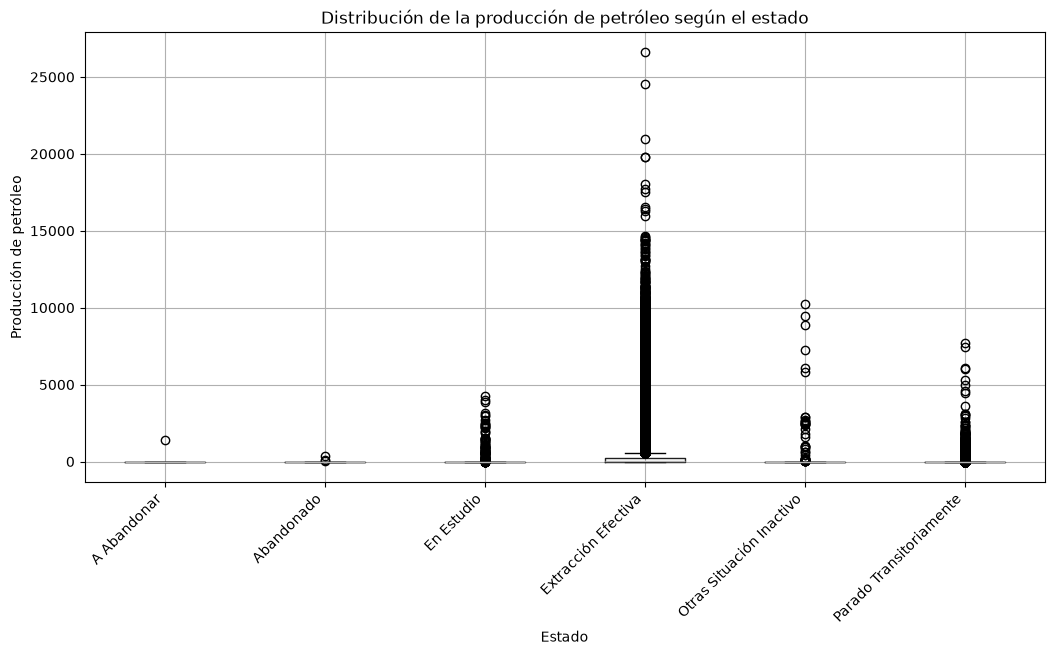

In [158]:
produccion_estados_principales = produccion[
    produccion["tipoestado"].isin(estados_principales)
]

produccion_estados_principales.boxplot(
    column="prod_pet",
    by="tipoestado",
    figsize=(12, 6)
)

plt.title("Distribución de la producción de petróleo según el estado")
plt.suptitle("")
plt.xlabel("Estado")
plt.ylabel("Producción de petróleo")
plt.xticks(rotation=45, ha="right")
plt.show()

El análisis de la producción según el estado muestra que `Extracción Efectiva` concentra la mayor cantidad de registros y presenta una proporción considerablemente mayor de observaciones con producción positiva respecto del resto de los estados analizados.

También observamos que las medianas de los principales estados se encuentran muy próximas a cero, mientras que los promedios son considerablemente mayores. Esto confirma nuevamente la fuerte asimetría de `prod_pet` y la presencia de una cola de valores elevados.

El boxplot permite observar este comportamiento, aunque la gran diferencia entre los valores bajos y los valores máximos dificulta la comparación visual entre algunas categorías. Por este motivo, para los siguientes análisis será importante considerar medidas robustas como la mediana y utilizar visualizaciones adecuadas para distribuciones sesgadas.

A partir de este análisis, `tipoestado` se presenta como una variable potencialmente relevante para explicar diferencias en la producción, aunque su utilización en el modelo deberá evaluarse posteriormente teniendo en cuenta la información disponible en el momento de realizar cada predicción.


#### 3.5. Relación entre producción y cuenca

Luego de analizar el estado de los registros, estudiamos la relación entre la producción de petróleo y la cuenca a la que pertenece cada pozo.

La variable `cuenca` permite incorporar información sobre el contexto geográfico y productivo de los pozos. Primero analizaremos la cantidad de registros y el comportamiento de `prod_pet` en cada cuenca, utilizando medidas como el promedio y la mediana.

Esto nos permitirá determinar si existen diferencias importantes en los niveles de producción entre las distintas cuencas antes de realizar una comparación visual.


In [159]:
resumen_produccion_cuenca = (
    produccion
    .groupby("cuenca")["prod_pet"]
    .agg(
        cantidad_registros="count",
        promedio="mean",
        mediana="median",
        minimo="min",
        maximo="max"
    )
    .sort_values("cantidad_registros", ascending=False)
)

display(resumen_produccion_cuenca)

,cantidad_registros,promedio,mediana,minimo,maximo
cuenca,,,,,
NEUQUINA,404037,346.620817,7.20497,0.000,26593.26100
AUSTRAL,16197,19.084589,11.53400,-0.001,543.93500
GOLFO SAN JORGE,627,198.833239,90.14111,0.000,1431.11600
NOROESTE,185,86.331332,0.00000,0.000,387.14578


##### 3.5.1. Distribución de la producción según cuenca

El resumen anterior muestra diferencias entre las cuencas, especialmente al comparar las medianas y los promedios de producción.

Para observar estas diferencias de manera visual, analizamos la distribución de `prod_pet` para cada cuenca mediante un diagrama de caja. Esta visualización permite comparar las medianas, la dispersión de los valores y la presencia de valores elevados dentro de cada grupo.

Debido a que la producción presenta una distribución fuertemente sesgada, debemos tener en cuenta que los valores extremos pueden afectar la escala del gráfico.


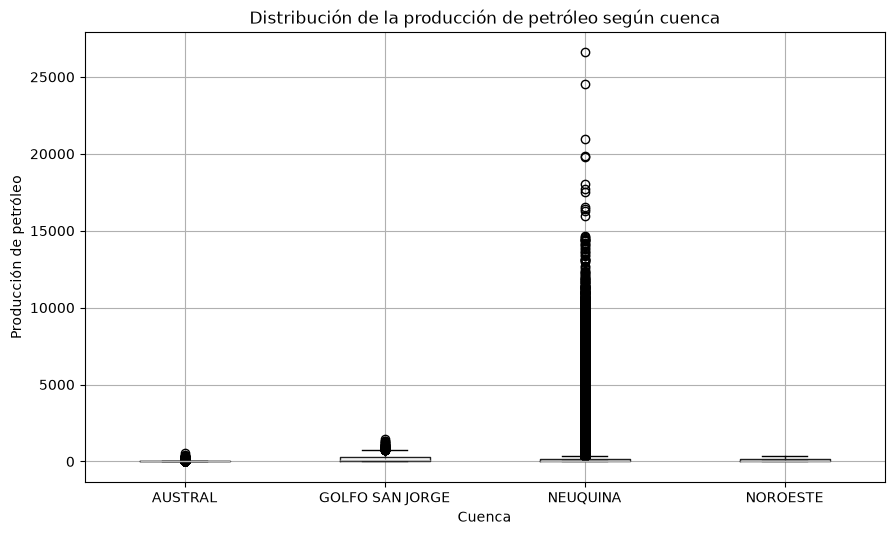

In [160]:
produccion.boxplot(
    column="prod_pet",
    by="cuenca",
    figsize=(10, 6)
)

plt.title("Distribución de la producción de petróleo según cuenca")
plt.suptitle("")
plt.xlabel("Cuenca")
plt.ylabel("Producción de petróleo")
plt.show()

##### 3.5.2. Conclusiones del análisis por cuenca

El análisis muestra diferencias entre las cuencas en los niveles de producción de petróleo. En particular, `GOLFO SAN JORGE` presenta una mediana de 90,14, mientras que `NEUQUINA` presenta una mediana de 7,20. `AUSTRAL` tiene una mediana de 11,53 y `NOROESTE` presenta una mediana de 0.

También se observa una diferencia importante entre los promedios y las medianas, especialmente en `NEUQUINA`, donde el promedio alcanza 346,62 mientras que la mediana es 7,20. Esto vuelve a mostrar la fuerte asimetría de la variable `prod_pet` y el efecto de los valores de producción elevados.

La visualización mediante boxplot permite observar esta asimetría, aunque la gran diferencia de escala entre los valores dificulta la comparación visual entre algunas cuencas. Por este motivo, para análisis posteriores será necesario complementar este tipo de gráficos con estadísticas descriptivas y otras visualizaciones.

Además, las cantidades de registros son muy diferentes entre las cuencas. `NEUQUINA` concentra 404.037 registros, mientras que `GOLFO SAN JORGE` y `NOROESTE` tienen una cantidad considerablemente menor. Por lo tanto, las diferencias observadas en estas últimas deben interpretarse teniendo en cuenta su menor representación en el dataset.

En función de estos resultados, `cuenca` se considera una variable potencialmente relevante para caracterizar la producción y podría ser evaluada posteriormente como variable predictora.


#### 3.6. Relación entre producción y formación

Luego de analizar la relación entre producción y cuenca, estudiamos la variable `formacion`, que describe la formación geológica asociada a cada registro.

El dataset contiene numerosas formaciones con cantidades de registros muy diferentes. Por este motivo, antes de comparar su producción, analizamos cómo se distribuyen los registros entre las distintas formaciones.

Esto nos permitirá identificar cuáles tienen una representación suficiente para realizar comparaciones y evitar conclusiones basadas en categorías con muy pocas observaciones.


In [161]:
registros_por_formacion = (
    produccion["formacion"]
    .value_counts()
    .rename("cantidad_registros")
)

display(registros_por_formacion)

formacion
vaca muerta               216445
lajas                      77407
mulichinco                 34749
los molles                 28011
magallanes                 15605
precuyo                    14603
quintuco                   10958
punta rosada                9577
agrio                       5671
basamento                   2172
lotena                      1595
formación improductiva       711
tordillo                     517
sierras blancas              466
chachao                      407
centenario                   404
pozo d-129                   385
ANITA                        209
palermo aike                 206
rayoso                       187
yacoraite                    185
springhill                   159
grupo chubut                 151
loma montosa                 126
mina el carmen                38
cañadon seco                  32
grupo neuquén                 31
bajo barreal                  21
tobífera                      18
Name: cantidad_registros, dtype: 

##### 3.6.1. Producción de petróleo según formación

Luego de conocer cómo se distribuyen los registros entre las distintas formaciones, analizamos el comportamiento de la producción de petróleo en cada una de ellas.

Para esto agrupamos los registros según formacion y calculamos la cantidad de observaciones, el promedio, la mediana y los valores mínimo y máximo de prod_pet.

La cantidad de registros nos permite conocer qué tan representada está cada formación, mientras que el promedio y la mediana nos permiten comparar sus niveles de producción. Incluimos ambas medidas porque anteriormente observamos que prod_pet presenta una distribución sesgada, por lo que el promedio puede verse afectado por valores de producción elevados.

In [162]:
resumen_produccion_formacion = (
    produccion
    .groupby("formacion")["prod_pet"]
    .agg(
        cantidad_registros="count",
        promedio="mean",
        mediana="median",
        minimo="min",
        maximo="max"
    )
    .sort_values("cantidad_registros", ascending=False)
)

display(resumen_produccion_formacion)

,cantidad_registros,promedio,mediana,minimo,maximo
formacion,,,,,
vaca muerta,216445,625.970863,69.680000,0.00000,26593.26100
lajas,77407,33.298582,0.088252,0.00000,3511.23100
mulichinco,34749,11.902193,0.460000,0.00000,1108.21600
los molles,28011,6.200870,1.230000,0.00000,667.17000
magallanes,15605,19.394056,11.851030,-0.00100,543.93500
precuyo,14603,10.294439,0.000000,0.00000,1205.81000
quintuco,10958,16.941804,0.000000,0.00000,4428.59000
punta rosada,9577,94.810026,24.990000,0.00000,2890.50000
agrio,5671,15.427872,0.000000,0.00000,1936.78000


##### 3.6.2. Selección de formaciones representativas

El análisis anterior muestra que la cantidad de registros varía considerablemente entre las distintas formaciones. Mientras que algunas concentran miles de observaciones, otras presentan una cantidad muy reducida de registros.

Para realizar una comparación visual más representativa, seleccionamos inicialmente las 10 formaciones con mayor cantidad de registros. Esta selección no implica descartar las demás categorías del dataset, sino limitar el análisis visual a aquellas que cuentan con una mayor representación.

Antes de continuar, calculamos qué proporción del total de registros representan estas formaciones para conocer qué tan representativo es este subconjunto.


El análisis anterior muestra que existen numerosas formaciones dentro del dataset, pero la cantidad de registros no se distribuye de manera uniforme.

Algunas formaciones concentran una gran cantidad de observaciones, mientras que otras tienen una representación muy reducida. Por este motivo, para continuar con el análisis nos enfocamos inicialmente en las formaciones con mayor cantidad de registros.

Esto permite realizar comparaciones con una cantidad de observaciones suficiente y evita darle el mismo peso a categorías con diferencias muy grandes en su representación.


In [163]:
top_10_formaciones = resumen_produccion_formacion.head(10)

cantidad_top_10 = top_10_formaciones["cantidad_registros"].sum()
cantidad_total = len(produccion)

porcentaje_top_10 = cantidad_top_10 / cantidad_total * 100

print("Cantidad de registros de las 10 principales formaciones:", cantidad_top_10)
print(f"Porcentaje del total de registros: {porcentaje_top_10:.2f}%")

Cantidad de registros de las 10 principales formaciones: 415198
Porcentaje del total de registros: 98.61%


##### 3.6.3. Mediana de producción según formación

Luego de seleccionar las formaciones con mayor representación, comparamos la producción de petróleo entre ellas utilizando la mediana de `prod_pet`.

Elegimos la mediana como medida principal porque el análisis anterior mostró que la producción presenta una distribución fuertemente sesgada hacia la derecha. En este contexto, la mediana resulta menos sensible a los valores de producción muy elevados que el promedio.

De esta manera podemos observar con mayor claridad las diferencias en el nivel de producción habitual entre las formaciones más representadas.


In [164]:
mediana_por_formacion = (
    top_10_formaciones
    .sort_values("mediana", ascending=False)
)

display(mediana_por_formacion[["cantidad_registros", "mediana"]])

,cantidad_registros,mediana
formacion,,
vaca muerta,216445,69.680000
punta rosada,9577,24.990000
magallanes,15605,11.851030
basamento,2172,1.375000
los molles,28011,1.230000
mulichinco,34749,0.460000
lajas,77407,0.088252
precuyo,14603,0.000000
quintuco,10958,0.000000


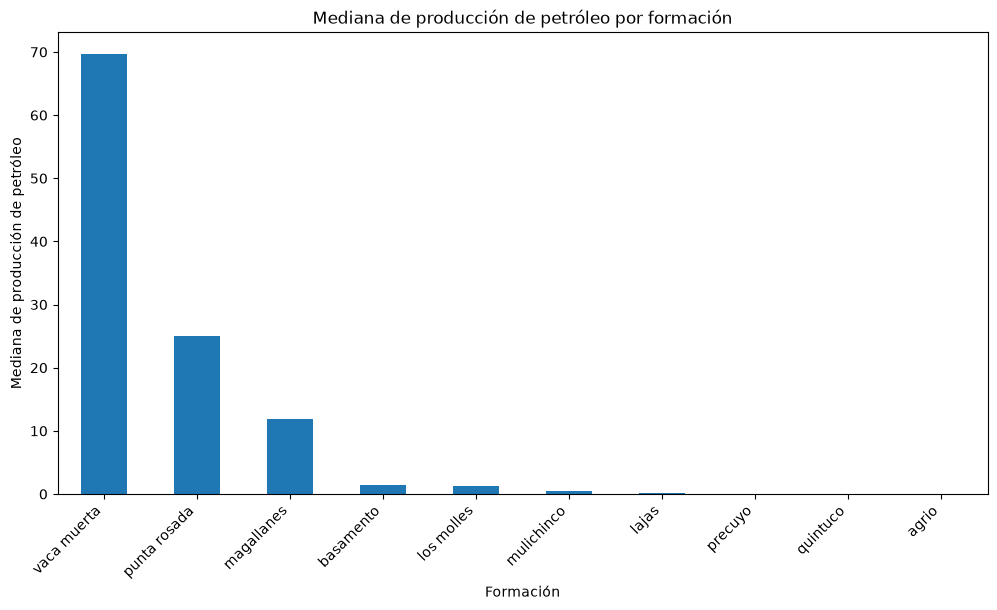

In [165]:
mediana_por_formacion["mediana"].plot(
    kind="bar",
    figsize=(12, 6),
    title="Mediana de producción de petróleo por formación"
)

plt.xlabel("Formación")
plt.ylabel("Mediana de producción de petróleo")
plt.xticks(rotation=45, ha="right")
plt.show()

##### 3.6.4. Producción positiva según formación

El análisis de la mediana mostró que algunas de las formaciones más representadas presentan una mediana de producción igual o cercana a cero.

Para comprender mejor este comportamiento, analizamos la cantidad y el porcentaje de registros que presentan producción de petróleo mayor a cero en cada formación.

Este análisis permite distinguir entre formaciones donde la mayoría de los registros presentan alguna producción y aquellas donde los registros con producción positiva representan una proporción menor.

De esta manera podemos interpretar mejor las medianas obtenidas anteriormente, sin asumir que los registros con producción igual a cero corresponden necesariamente a pozos inactivos o a un problema en los datos.


In [166]:
produccion_por_formacion = (
    produccion
    .groupby("formacion")
    .agg(
        cantidad_registros=("prod_pet", "count"),
        registros_con_produccion=("prod_pet", lambda x: (x > 0).sum())
    )
)

produccion_por_formacion["porcentaje_con_produccion"] = (
    produccion_por_formacion["registros_con_produccion"]
    / produccion_por_formacion["cantidad_registros"]
    * 100
)

produccion_por_formacion = produccion_por_formacion.sort_values(
    "cantidad_registros",
    ascending=False
)

display(produccion_por_formacion)

,cantidad_registros,registros_con_produccion,porcentaje_con_produccion
formacion,,,
vaca muerta,216445,158079,73.034258
lajas,77407,39692,51.277016
mulichinco,34749,20265,58.318225
los molles,28011,17128,61.147406
magallanes,15605,13623,87.298943
precuyo,14603,5749,39.368623
quintuco,10958,5261,48.010586
punta rosada,9577,7543,78.761616
agrio,5671,2473,43.607829


##### 3.6.5. Nivel de producción cuando es positiva

El análisis anterior permitió observar que la proporción de registros con producción positiva varía considerablemente entre las formaciones.

Sin embargo, este indicador no muestra cuánto petróleo producen los registros cuando efectivamente existe producción. Por este motivo, en este análisis filtramos los registros con `prod_pet > 0` y calculamos nuevamente la cantidad de observaciones, el promedio, la mediana y los valores mínimo y máximo para cada formación.

De esta manera podemos diferenciar dos aspectos del comportamiento productivo: la frecuencia con la que se registra producción y el nivel de producción observado cuando esta es positiva.


In [167]:
produccion_positiva = produccion[produccion["prod_pet"] > 0]

resumen_produccion_positiva_formacion = (
    produccion_positiva
    .groupby("formacion")["prod_pet"]
    .agg(
        cantidad_registros="count",
        promedio="mean",
        mediana="median",
        minimo="min",
        maximo="max"
    )
    .sort_values("cantidad_registros", ascending=False)
)

display(resumen_produccion_positiva_formacion)

,cantidad_registros,promedio,mediana,minimo,maximo
formacion,,,,,
vaca muerta,158079,857.092109,276.440000,0.001053,26593.26100
lajas,39692,64.938612,17.502000,0.004011,3511.23100
mulichinco,20265,20.409045,5.350000,0.000001,1108.21600
los molles,17128,10.140856,3.780000,0.009522,667.17000
magallanes,13623,22.215682,14.222950,0.010000,543.93500
punta rosada,7543,120.375927,46.900000,0.000002,2890.50000
precuyo,5749,26.148842,9.020853,0.010000,1205.81000
quintuco,5261,35.287644,9.600000,0.001264,4428.59000
agrio,2473,35.378674,2.172183,0.000009,1936.78000


##### 3.6.6. Comparación de las formaciones más representadas

Luego de analizar la proporción de registros con producción positiva y el comportamiento de `prod_pet` cuando la producción es mayor a cero, comparamos las 10 formaciones con mayor cantidad de registros.

Para esta comparación utilizamos la mediana de `prod_pet` considerando únicamente los registros con producción positiva. De esta manera evitamos que la presencia de registros con producción igual a cero oculte las diferencias en los niveles de producción observados cuando existe producción.

La comparación se limita a las 10 formaciones más representadas para evitar que categorías con muy pocas observaciones condicionen la interpretación.


In [168]:
top_10_positivas = (
    resumen_produccion_positiva_formacion
    .loc[top_10_formaciones.index]
    .sort_values("mediana", ascending=False)
)

display(
    top_10_positivas[
        ["cantidad_registros", "mediana"]
    ]
)

,cantidad_registros,mediana
formacion,,
vaca muerta,158079,276.440000
punta rosada,7543,46.900000
lajas,39692,17.502000
magallanes,13623,14.222950
quintuco,5261,9.600000
precuyo,5749,9.020853
mulichinco,20265,5.350000
basamento,1299,4.880000
los molles,17128,3.780000


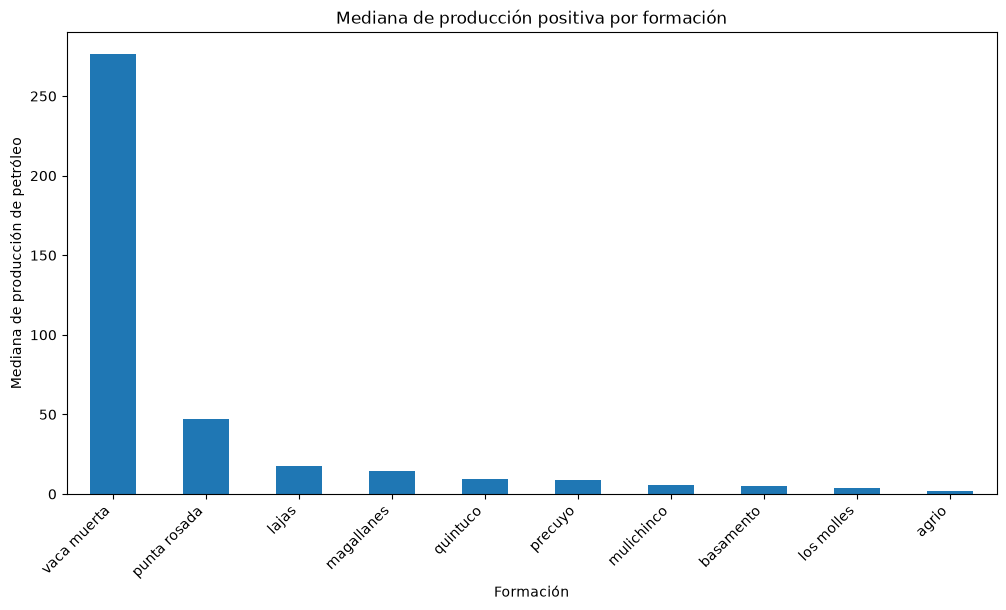

In [169]:
top_10_positivas["mediana"].plot(
    kind="bar",
    figsize=(12, 6),
    title="Mediana de producción positiva por formación"
)

plt.xlabel("Formación")
plt.ylabel("Mediana de producción de petróleo")
plt.xticks(rotation=45, ha="right")
plt.show()

##### 3.6.7. Conclusiones del análisis por formación

El análisis de la variable `formacion` muestra diferencias importantes tanto en la cantidad de registros disponibles como en el comportamiento de la producción de petróleo.

`Vaca Muerta` es la formación con mayor representación en el dataset, con 216.445 registros. Además, el 73,03% de sus registros presenta producción de petróleo positiva y, considerando únicamente estos registros, la mediana de producción alcanza 276,44.

También se observan diferencias entre otras formaciones. Por ejemplo, `Punta Rosada` presenta un 78,76% de registros con producción positiva y una mediana de producción positiva de 46,90, mientras que `Lajas` presenta un 51,28% de registros con producción positiva y una mediana positiva de 17,50.

Por otro lado, algunas formaciones presentan valores elevados de producción positiva pero cuentan con una cantidad de registros mucho menor. Por este motivo, sus resultados deben interpretarse con mayor cautela y no compararse directamente con formaciones que tienen una representación mucho mayor.

En conjunto, los resultados muestran que `formacion` contiene información que podría ser relevante para explicar diferencias en el comportamiento de la producción de petróleo. Sin embargo, para el desarrollo del modelo será necesario considerar también otras variables y, especialmente, la información histórica disponible hasta el momento de realizar cada predicción.


### 4. Formateo y transformación de los datos

Luego de explorar la estructura, calidad y comportamiento de los datos, en esta sección realizamos las transformaciones necesarias para preparar los datasets para las siguientes etapas del proyecto.

El objetivo no es modificar los datos originales, sino generar copias de trabajo sobre las cuales podamos convertir tipos de datos, eliminar información que no aporte valor y preparar las variables que posteriormente utilizaremos para el análisis y los modelos de Machine Learning.

En particular, en esta etapa revisaremos columnas con valores constantes, convertiremos las variables de fecha a un formato adecuado y eliminaremos o dejaremos identificadas aquellas variables que resulten redundantes.


#### 4.1. Creación de copias de trabajo

Para conservar los datasets originales tal como fueron cargados, trabajaremos sobre copias de cada uno de ellos.

De esta manera podemos realizar las transformaciones necesarias sin modificar los datos originales. Esto también nos permite volver a la versión inicial en caso de detectar algún problema durante el proceso de preparación.


In [170]:
produccion_limpio = produccion.copy()
pozos_limpio = pozos.copy()
fracturacion_limpio = fracturacion.copy()

#### 4.2. Identificación de columnas con un único valor

Antes de realizar otras transformaciones, revisamos si existen columnas que contienen un único valor en todos sus registros.

Una variable con un solo valor no permite diferenciar una observación de otra, por lo que no aporta información para los modelos predictivos. Sin embargo, primero las identificamos y analizamos antes de decidir si corresponde eliminarlas.

Para detectar estas columnas utilizamos `nunique()`, que permite conocer la cantidad de valores diferentes presentes en cada variable.


In [171]:
print("Columnas con un único valor - Producción:")
display(produccion_limpio.nunique()[produccion_limpio.nunique() == 1])

print("Columnas con un único valor - Pozos:")
display(pozos_limpio.nunique()[pozos_limpio.nunique() == 1])

print("Columnas con un único valor - Fracturación:")
display(fracturacion_limpio.nunique()[fracturacion_limpio.nunique() == 1])

Columnas con un único valor - Producción:


iny_co2            1
iny_otro           1
habilitado         1
tipo_de_recurso    1
dtype: int64

Columnas con un único valor - Pozos:


Series([], dtype: int64)

Columnas con un único valor - Fracturación:


Series([], dtype: int64)

En el dataset de producción encontramos cuatro columnas con un único valor.

Las variables `iny_co2` e `iny_otro` tienen valor cero en todos los registros, por lo que no presentan variabilidad dentro de este dataset. La variable `habilitado` también tiene un único valor, lo que indica que todos los registros se encuentran habilitados.

Por otro lado, `tipo_de_recurso` contiene únicamente el valor `NO CONVENCIONAL`, lo cual es esperable debido a que el dataset seleccionado corresponde específicamente a producción de pozos no convencionales.

Por el momento no eliminamos estas variables de los datasets de trabajo. Las dejamos identificadas para decidir posteriormente cuáles serán necesarias al seleccionar las variables que participarán en los modelos.


#### 4.3. Conversión de fechas

Durante la exploración inicial observamos que varias variables relacionadas con fechas fueron importadas como texto (`str`).

Para poder ordenar registros cronológicamente, calcular diferencias entre fechas y realizar análisis temporales, necesitamos convertir estas variables al tipo de dato correspondiente.

Utilizaremos `pd.to_datetime()` para realizar las conversiones. Cuando sea necesario especificaremos el formato esperado y utilizaremos `errors="coerce"` para que cualquier valor que no pueda convertirse quede registrado como `NaT` (`Not a Time`) en lugar de interrumpir la ejecución.

Después de cada conversión verificaremos si se generaron nuevos valores faltantes.


##### 4.3.1. Fechas del dataset de producción

El dataset de producción contiene dos variables relacionadas con fechas: `fechaingreso` y `fecha_data`.

Primero revisamos algunos valores de `fechaingreso` para identificar el formato utilizado antes de realizar la conversión.


In [172]:
print("Primeros valores de 'fechaingreso':")
display(produccion_limpio["fechaingreso"].head())

Primeros valores de 'fechaingreso':


0    2015-02-26 13:35:35.533458
1    2018-02-10 08:37:14.717426
2    2017-02-16 13:45:37.233373
3    2018-02-10 08:37:14.717426
4    2016-02-17 10:50:46.929347
Name: fechaingreso, dtype: str

Los valores contienen la fecha, la hora y fracciones de segundo, siguiendo el formato `año-mes-día hora:minutos:segundos.microsegundos`.

Por este motivo utilizamos el formato `%Y-%m-%d %H:%M:%S.%f` para realizar la conversión.

Primero guardamos el resultado en una variable separada para comprobar que la conversión sea correcta antes de reemplazar la columna original.


In [173]:
fechaingreso_convertida = pd.to_datetime(
    produccion_limpio["fechaingreso"],
    format="%Y-%m-%d %H:%M:%S.%f",
    errors="coerce"
)

print(
    "Valores que no pudieron convertirse:",
    fechaingreso_convertida.isna().sum()
)

Valores que no pudieron convertirse: 0


No se generaron valores `NaT`, por lo que todas las fechas informadas pudieron convertirse correctamente.

Antes de reemplazar la columna original, verificamos también el tipo de dato obtenido.


In [174]:
print(
    "Tipo de dato de 'fechaingreso' convertida:",
    fechaingreso_convertida.dtype
)

Tipo de dato de 'fechaingreso' convertida: datetime64[us]


In [175]:
print("Fecha de ingreso mínima:", fechaingreso_convertida.min())
print("Fecha de ingreso máxima:", fechaingreso_convertida.max())

Fecha de ingreso mínima: 2006-11-13 13:57:53.058895
Fecha de ingreso máxima: 2026-08-21 12:03:20.911612


Las fechas de `fechaingreso` abarcan desde noviembre de 2006 hasta agosto de 2026 y fueron convertidas correctamente al tipo fecha.

Sin embargo, esta variable representa la fecha en la que el registro fue ingresado o cargado en el sistema y no necesariamente el período al que corresponde la producción.

Esto se observa al comparar su fecha máxima con el período de producción disponible. Por este motivo, `fechaingreso` no será utilizada como referencia principal para ordenar la producción temporalmente.


Una vez comprobado que todos los valores pudieron convertirse correctamente, reemplazamos la columna original fechaingreso en produccion_limpio por su versión en formato fecha.

De esta manera, la copia de trabajo queda preparada para utilizar esta variable en caso de necesitarla posteriormente.

In [176]:
produccion_limpio["fechaingreso"] = fechaingreso_convertida

print("Primeros valores de 'fecha_data' en producción:")
display(produccion_limpio["fecha_data"].head())

Primeros valores de 'fecha_data' en producción:


0    2015-01-31
1    2018-01-31
2    2017-01-31
3    2018-01-31
4    2016-01-31
Name: fecha_data, dtype: str

##### 4.3.2. Conversión de `fecha_data`

La variable `fecha_data` contiene la fecha correspondiente al período de producción y se encuentra almacenada como texto.

A diferencia de `fechaingreso`, esta variable resulta especialmente importante para nuestro análisis temporal porque permite identificar el período al que corresponde cada registro de producción.


In [177]:
print("Primeros valores de 'fecha_data':")
display(produccion_limpio["fecha_data"].head())

Primeros valores de 'fecha_data':


0    2015-01-31
1    2018-01-31
2    2017-01-31
3    2018-01-31
4    2016-01-31
Name: fecha_data, dtype: str

In [178]:
produccion_limpio["fecha_data"] = pd.to_datetime(
    produccion_limpio["fecha_data"],
    format="%Y-%m-%d",
    errors="coerce"
)

print("Valores que no pudieron convertirse:", produccion_limpio["fecha_data"].isna().sum())

Valores que no pudieron convertirse: 0


Todos los valores se convirtieron correctamente.

Para comprobar que `fecha_data` representa correctamente el período informado, verificamos que el año y el mes obtenidos a partir de esta fecha coincidan con las variables `anio` y `mes`.

Si ambas representaciones coinciden, podemos utilizar `fecha_data` como referencia temporal sin perder la información contenida en `anio` y `mes`.


In [179]:
coincide_anio = produccion_limpio["fecha_data"].dt.year == produccion_limpio["anio"]
coincide_mes = produccion_limpio["fecha_data"].dt.month == produccion_limpio["mes"]

print("Registros donde 'fecha_data' coincide con 'anio' y 'mes':", (coincide_anio & coincide_mes).sum())
print("Total de registros:", len(produccion_limpio))

Registros donde 'fecha_data' coincide con 'anio' y 'mes': 421046
Total de registros: 421046


Los 421.046 registros presentan coincidencia entre el año y el mes de fecha_data y los valores de anio y mes.

Esto confirma que fecha_data representa correctamente el período al que corresponde cada registro de producción y que puede utilizarse como variable temporal para ordenar la información.

A partir de este punto, utilizaremos fecha_data como referencia temporal del dataset de producción, mientras que fechaingreso quedará identificada como una fecha relacionada con la carga del registro.

##### 4.3.3. Fechas del dataset de pozos

El dataset de pozos tiene cuatro fechas: inicio y fin de la perforación, e inicio y fin de la terminación. Todas tienen el formato `año-mes-día`.

Como son varias columnas con el mismo formato, las recorremos con un `for` y aplicamos la misma conversión a cada una.

En este caso, las columnas ya tenían valores faltantes antes de convertirlas (lo vimos en la sección 2.6.2). Por eso comparamos la cantidad de nulos antes y después: si la cantidad aumenta, significa que algunos valores no pudieron convertirse.

In [180]:
fechas_pozos = [
    "adjiv_fecha_inicio_perf",
    "adjiv_fecha_fin_perf",
    "adjiv_fecha_inicio_term",
    "adjiv_fecha_fin_term"
]

for columna in fechas_pozos:
    nulos_antes = pozos_limpio[columna].isna().sum()

    pozos_limpio[columna] = pd.to_datetime(
        pozos_limpio[columna],
        format="%Y-%m-%d",
        errors="coerce"
    )

    nulos_despues = pozos_limpio[columna].isna().sum()

    print(f"{columna}: {nulos_despues - nulos_antes} valores no pudieron convertirse")

adjiv_fecha_inicio_perf: 0 valores no pudieron convertirse
adjiv_fecha_fin_perf: 0 valores no pudieron convertirse
adjiv_fecha_inicio_term: 0 valores no pudieron convertirse
adjiv_fecha_fin_term: 0 valores no pudieron convertirse


La conversión de las cuatro variables se realizó correctamente y no generó nuevos valores faltantes.

Los valores que ya eran faltantes se mantienen como `NaT`, mientras que todas las fechas informadas pudieron convertirse al tipo correspondiente.


##### 4.3.4. Fechas del dataset de fracturación

El dataset de fracturación contiene las fechas de inicio y finalización de las fracturas, además de fecha_data.

Antes de convertirlas revisamos algunos valores para confirmar el formato utilizado en cada variable.

In [181]:
print("Primeros valores de las fechas de fracturación:")

display(
    fracturacion_limpio[
        [
            "fecha_inicio_fractura",
            "fecha_fin_fractura",
            "fecha_data"
        ]
    ].head()
)

Primeros valores de las fechas de fracturación:


,fecha_inicio_fractura,fecha_fin_fractura,fecha_data
0,2019-04-20,2019-04-30,2019-06-14 17:13:03.68279
1,2018-11-02,2018-11-03,2019-06-14 17:14:19.179874
2,2017-11-19,2017-12-14,2019-06-27 13:46:21.14935
3,2017-11-21,2017-12-15,2019-06-27 13:46:21.14935
4,2017-11-18,2017-12-15,2019-06-27 13:46:21.14935


In [182]:
fracturacion_limpio["fecha_inicio_fractura"] = pd.to_datetime(
    fracturacion_limpio["fecha_inicio_fractura"],
    format="%Y-%m-%d",
    errors="coerce"
)

fracturacion_limpio["fecha_fin_fractura"] = pd.to_datetime(
    fracturacion_limpio["fecha_fin_fractura"],
    format="%Y-%m-%d",
    errors="coerce"
)

fracturacion_limpio["fecha_data"] = pd.to_datetime(
    fracturacion_limpio["fecha_data"],
    format="%Y-%m-%d %H:%M:%S.%f",
    errors="coerce"
)

print("Valores que no pudieron convertirse:")
print("fecha_inicio_fractura:", fracturacion_limpio["fecha_inicio_fractura"].isna().sum())
print("fecha_fin_fractura:", fracturacion_limpio["fecha_fin_fractura"].isna().sum())
print("fecha_data:", fracturacion_limpio["fecha_data"].isna().sum())

Valores que no pudieron convertirse:
fecha_inicio_fractura: 0
fecha_fin_fractura: 0
fecha_data: 0


Las tres fechas se convirtieron sin problemas.

#### 4.4. Identificación de variables redundantes

Durante la revisión del dataset de fracturación observamos que existen dos pares de variables que podrían estar representando la misma información:

* `anio` y `anio_if`
* `mes` y `mes_if`

Antes de eliminar alguna de ellas, verificamos si sus valores coinciden en todos los registros.


In [183]:
print("Registros donde 'anio' coincide con 'anio_if':", (fracturacion_limpio["anio"] == fracturacion_limpio["anio_if"]).sum())
print("Registros donde 'mes' coincide con 'mes_if':", (fracturacion_limpio["mes"] == fracturacion_limpio["mes_if"]).sum())
print("Total de registros:", len(fracturacion_limpio))

Registros donde 'anio' coincide con 'anio_if': 4890
Registros donde 'mes' coincide con 'mes_if': 4890
Total de registros: 4890


Los valores de `anio` y `anio_if` coinciden en los 4.890 registros, al igual que `mes` y `mes_if`.

Por lo tanto, ambas versiones contienen la misma información dentro de este dataset. Para evitar mantener variables duplicadas durante las siguientes etapas, conservaremos una sola representación de año y mes cuando definamos las variables que utilizaremos para el análisis y los modelos.


#### 4.5. Columnas de tipo sí/no

Algunas columnas solo indican si algo se cumple o no, pero están guardadas como texto:

- `rectificado` y `habilitado`, en producción, usan `t` (verdadero) y `f` (falso);
- `gasplus`, en pozos, usa `si` y `no`.

Primero revisamos qué valores tienen.

In [184]:
print("Valores de 'rectificado':")
display(produccion_limpio["rectificado"].value_counts())

print("Valores de 'habilitado':")
display(produccion_limpio["habilitado"].value_counts())

print("Valores de 'gasplus':")
display(pozos_limpio["gasplus"].value_counts())

Valores de 'rectificado':


rectificado
f    420352
t       694
Name: count, dtype: int64

Valores de 'habilitado':


habilitado
t    421046
Name: count, dtype: int64

Valores de 'gasplus':


gasplus
no    84497
si     1114
Name: count, dtype: int64

Las tres columnas solo tienen los dos valores esperados y no tienen nulos, así que podemos convertirlas a tipo booleano (`True` / `False`) sin perder información.

Para eso reemplazamos cada texto por su valor booleano usando `replace()` con un diccionario, y después indicamos el tipo con `astype(bool)`.

In [185]:
produccion_limpio["rectificado"] = produccion_limpio["rectificado"].replace({"t": True, "f": False}).astype(bool)
produccion_limpio["habilitado"] = produccion_limpio["habilitado"].replace({"t": True, "f": False}).astype(bool)
pozos_limpio["gasplus"] = pozos_limpio["gasplus"].replace({"si": True, "no": False}).astype(bool)

print("Valores de 'rectificado':")
display(produccion_limpio["rectificado"].value_counts())

print("Valores de 'gasplus':")
display(pozos_limpio["gasplus"].value_counts())

Valores de 'rectificado':


rectificado
False    420352
True        694
Name: count, dtype: int64

Valores de 'gasplus':


gasplus
False    84497
True      1114
Name: count, dtype: int64

La conversión mantuvo las mismas cantidades que antes: 694 registros de producción fueron rectificados y 1.114 pozos pertenecen al programa Gas Plus.

#### 4.6. Estandarización de las formaciones

Las formaciones aparecen en los tres datasets, y más adelante nos va a interesar compararlas entre sí. Para eso es importante que el mismo nombre esté escrito siempre de la misma forma. Veamos cómo están escritas en producción.

In [186]:
print("Formaciones en producción:")
print(produccion_limpio["formacion"].unique())

Formaciones en producción:
<StringArray>
[               'precuyo',                  'lajas', 'formación improductiva',
               'quintuco',              'basamento',            'vaca muerta',
                 'lotena',             'los molles',           'punta rosada',
             'mulichinco',           'grupo chubut',        'sierras blancas',
                  'agrio',             'centenario',                 'rayoso',
          'grupo neuquén',                'chachao',             'pozo d-129',
               'tordillo',         'mina el carmen',           'loma montosa',
              'yacoraite',             'magallanes',           'palermo aike',
             'springhill',                  'ANITA',               'tobífera',
           'cañadon seco',           'bajo barreal']
Length: 29, dtype: str


Casi todas las formaciones están en minúsculas, excepto `ANITA`, que está en mayúsculas. En el dataset de pozos, además, encontramos nombres que empiezan con mayúscula (como `Piedra Clavada`) y dos formaciones con un espacio de más al final (`glauconitico ` y `lonco trapial `).

Para que todas queden escritas igual, las pasamos a mayúsculas con `.str.upper()`, que es el mismo formato que ya usan otras columnas como `cuenca`. Los dos casos con espacio al final los corregimos con `replace()`.

In [187]:
produccion_limpio["formacion"] = produccion_limpio["formacion"].str.upper()
pozos_limpio["formacion"] = pozos_limpio["formacion"].str.upper()
fracturacion_limpio["formacion_productiva"] = fracturacion_limpio["formacion_productiva"].str.upper()

pozos_limpio["formacion"] = pozos_limpio["formacion"].replace({
    "GLAUCONITICO ": "GLAUCONITICO",
    "LONCO TRAPIAL ": "LONCO TRAPIAL"
})

print("Formaciones en producción:")
print(produccion_limpio["formacion"].unique())

Formaciones en producción:
<StringArray>
[               'PRECUYO',                  'LAJAS', 'FORMACIÓN IMPRODUCTIVA',
               'QUINTUCO',              'BASAMENTO',            'VACA MUERTA',
                 'LOTENA',             'LOS MOLLES',           'PUNTA ROSADA',
             'MULICHINCO',           'GRUPO CHUBUT',        'SIERRAS BLANCAS',
                  'AGRIO',             'CENTENARIO',                 'RAYOSO',
          'GRUPO NEUQUÉN',                'CHACHAO',             'POZO D-129',
               'TORDILLO',         'MINA EL CARMEN',           'LOMA MONTOSA',
              'YACORAITE',             'MAGALLANES',           'PALERMO AIKE',
             'SPRINGHILL',                  'ANITA',               'TOBÍFERA',
           'CAÑADON SECO',           'BAJO BARREAL']
Length: 29, dtype: str


Ahora todas las formaciones están escritas en mayúsculas y con el mismo formato en los tres datasets.

#### 4.7. Resumen del formateo

Para terminar, verificamos que las columnas que modificamos tengan el tipo de dato correcto.

In [188]:
print("Tipos de datos de las columnas formateadas - Producción:")
display(produccion_limpio[["fechaingreso", "fecha_data", "rectificado", "habilitado"]].dtypes)

print("Tipos de datos de las columnas formateadas - Pozos:")
display(pozos_limpio[fechas_pozos + ["gasplus"]].dtypes)

print("Tipos de datos de las columnas formateadas - Fracturación:")
display(fracturacion_limpio[["fecha_inicio_fractura", "fecha_fin_fractura", "fecha_data"]].dtypes)

Tipos de datos de las columnas formateadas - Producción:


fechaingreso    datetime64[us]
fecha_data      datetime64[us]
rectificado               bool
habilitado                bool
dtype: object

Tipos de datos de las columnas formateadas - Pozos:


adjiv_fecha_inicio_perf    datetime64[us]
adjiv_fecha_fin_perf       datetime64[us]
adjiv_fecha_inicio_term    datetime64[us]
adjiv_fecha_fin_term       datetime64[us]
gasplus                              bool
dtype: object

Tipos de datos de las columnas formateadas - Fracturación:


fecha_inicio_fractura    datetime64[us]
fecha_fin_fractura       datetime64[us]
fecha_data               datetime64[us]
dtype: object

Todas las fechas quedaron con tipo `datetime64` y las columnas de sí/no con tipo `bool`.

En resumen, en esta sección:

- identificamos cuatro columnas de producción con un único valor y dos columnas repetidas en fracturación;
- convertimos a tipo fecha todas las fechas que estaban guardadas como texto;
- comprobamos que `fecha_data` representa el período de producción de cada registro;
- convertimos a booleano las columnas de tipo sí/no;
- unificamos la forma en que están escritas las formaciones.

En ningún caso eliminamos registros ni columnas.

### 5. Valores mínimos y máximos

Con los datos ya formateados, revisamos los valores mínimos y máximos de las principales variables de cada dataset.

La idea es comprobar si los valores tienen sentido. Por ejemplo, una producción no puede ser negativa y un mes no puede tener más de 31 días. Si encontramos valores que no son posibles, los identificamos para decidir más adelante qué hacer con ellos.

#### 5.1. Dataset de producción

In [189]:
variables_rango_produccion = [
    "prod_pet",
    "prod_gas",
    "prod_agua",
    "tef",
    "profundidad",
    "coordenadax",
    "coordenaday"
]

display(produccion_limpio[variables_rango_produccion].agg(["min", "max"]).T)

,min,max
prod_pet,-0.00100,26593.26100
prod_gas,-12.26700,40086.80000
prod_agua,0.00000,34792.95000
tef,0.00000,79.34000
profundidad,0.00000,378939.00000
coordenadax,-71.99831,-38.59007
coordenaday,-69.41577,-24.11656


A primera vista aparecen varios valores que llaman la atención:

- `prod_pet` y `prod_gas` tienen valores mínimos negativos;
- `tef` llega a 79,34, cuando representa los días efectivos de producción en un mes;
- `profundidad` tiene valores de 0 y un máximo de 378.939 metros;
- `coordenadax` tiene un máximo de -38,59 y `coordenaday` un mínimo de -69,42, que parecen estar invertidos.

Vamos a revisar cada caso por separado.

Empezamos por los registros con producción negativa.

In [190]:
registros_negativos = produccion_limpio[
    (produccion_limpio["prod_pet"] < 0) | (produccion_limpio["prod_gas"] < 0)
]

display(registros_negativos[["idpozo", "anio", "mes", "prod_pet", "prod_gas", "tef", "tipopozo", "tipoestado"]])

,idpozo,anio,mes,prod_pet,prod_gas,tef,tipopozo,tipoestado
300275,153228,2020,5,1.670,-12.267,6.13,Gasífero,Extracción Efectiva
300283,153227,2020,5,1.020,-7.519,6.13,Gasífero,Extracción Efectiva
323445,73804,2008,12,-0.001,0.000,0.00,Gasífero,En Estudio


Son solo tres registros: dos pozos con producción de gas negativa en mayo de 2020 y el registro con producción de petróleo de -0,001 que ya habíamos encontrado en la sección 3.3.1.

Una producción negativa no es posible: significaría que en ese mes el pozo, en lugar de extraer, recibió petróleo o gas, es decir, que funcionó como un sumidero. Sin embargo, los tres son pozos gasíferos, no sumideros ni pozos de inyección.

Una explicación posible es un error de signo: que el valor correcto sea el mismo, pero positivo. Para evaluarlo, revisamos la producción de cada pozo en los dos meses anteriores y los dos posteriores al registro negativo.

In [191]:
for pozo in registros_negativos["idpozo"].unique():
    fecha = registros_negativos.loc[registros_negativos["idpozo"] == pozo, "fecha_data"].iloc[0]

    historial = produccion_limpio[
        (produccion_limpio["idpozo"] == pozo)
        & (produccion_limpio["fecha_data"] >= fecha - pd.DateOffset(months=2))
        & (produccion_limpio["fecha_data"] <= fecha + pd.DateOffset(months=2))
    ].sort_values("fecha_data")

    print(f"Pozo {pozo}:")
    display(historial[["anio", "mes", "prod_pet", "prod_gas", "tef", "tipoestado"]])

Pozo 153228:


,anio,mes,prod_pet,prod_gas,tef,tipoestado
297352,2020,3,4.86,208.323,19.75,Extracción Efectiva
298924,2020,4,6.35,242.473,23.38,Extracción Efectiva
300275,2020,5,1.67,-12.267,6.13,Extracción Efectiva
302945,2020,6,1.23,22.053,4.63,Extracción Efectiva
304497,2020,7,1.06,29.996,3.79,Extracción Efectiva


Pozo 153227:


,anio,mes,prod_pet,prod_gas,tef,tipoestado
297356,2020,3,2.99,127.682,19.75,Extracción Efectiva
298942,2020,4,3.89,148.613,23.38,Extracción Efectiva
300283,2020,5,1.02,-7.519,6.13,Extracción Efectiva
302957,2020,6,0.76,13.516,4.63,Extracción Efectiva
304515,2020,7,0.65,18.384,3.79,Extracción Efectiva


Pozo 73804:


,anio,mes,prod_pet,prod_gas,tef,tipoestado
322228,2008,10,6.515,1099.40,10.0,Extracción Efectiva
322958,2008,11,2.825,938.94,12.0,En Estudio
323445,2008,12,-0.001,0.00,0.0,En Estudio
317270,2009,1,0.000,0.00,0.0,En Estudio
317956,2009,2,0.000,0.00,0.0,En Estudio


En los dos pozos con gas negativo, la hipótesis del error de signo es coherente. Ambos venían produciendo gas en abril (242,47 y 148,61) y siguieron haciéndolo en junio (22,05 y 13,52). En mayo solo produjeron 6,13 días, por lo que valores de 12,27 y 7,52, en positivo, encajan en esa caída. Además, los dos pozos tienen exactamente los mismos días efectivos en todos los meses observados, lo que sugiere que se informan juntos, y el valor negativo aparece en ambos en el mismo mes.

El caso del petróleo es distinto. El valor es -0,001, prácticamente cero: en ese mes el pozo estaba `En Estudio` y tuvo 0 días efectivos, y en los meses siguientes su producción es 0. Más que un cambio de signo, lo más probable es que su valor real sea 0.

Otra posibilidad es que los valores negativos sean ajustes de meses anteriores. Al ser solo tres registros, no afectan al análisis general, pero antes de entrenar los modelos habrá que decidir cómo tratarlos. Las opciones más razonables son invertir el signo de los dos registros de gas y reemplazar por 0 el de petróleo.

Seguimos con `tef` (tiempo efectivo), que indica cuántos días produjo el pozo durante el mes. Por lo tanto, nunca puede superar la cantidad de días de ese mes: 31 en enero, 30 en junio o 28 en febrero, por ejemplo.

Un primer control es contar los registros con más de 31 días, que son imposibles en cualquier mes. Sin embargo, este control no detecta, por ejemplo, un registro de junio con 30,5 días. Por eso comparamos también cada valor con los días reales de su mes, que obtenemos a partir de `fecha_data` con `.dt.days_in_month`.

Además, contamos cuántos registros tienen 0 días y verificamos que no haya registros duplicados para un mismo pozo y mes.

In [192]:
dias_del_mes = produccion_limpio["fecha_data"].dt.days_in_month
tef_imposible = produccion_limpio[produccion_limpio["tef"] > dias_del_mes]

print("Registros con 'tef' mayor a 31 días:", (produccion_limpio["tef"] > 31).sum())
print("Registros con 'tef' mayor a los días del mes:", len(tef_imposible))
print("De ellos, correspondientes a 2025 y 2026:", (tef_imposible["anio"] >= 2025).sum())
print("Registros con 'tef' igual a 0:", (produccion_limpio["tef"] == 0).sum())
print("Registros duplicados para un mismo pozo y mes:", produccion_limpio.duplicated(["idpozo", "fecha_data"]).sum())

Registros con 'tef' mayor a 31 días: 15
Registros con 'tef' mayor a los días del mes: 71
De ellos, correspondientes a 2025 y 2026: 34
Registros con 'tef' igual a 0: 81867
Registros duplicados para un mismo pozo y mes: 0


Hay 15 registros con más de 31 días efectivos, pero al compararlos con los días reales de cada mes los registros imposibles son 71. De ellos, 34 corresponden a 2025 y 2026.

Los registros con 0 días son muchos más (81.867), pero en este caso el valor sí tiene sentido: representa meses en los que el pozo no estuvo produciendo.

Tampoco hay registros duplicados: cada pozo tiene un único registro por mes, por lo que los valores imposibles no se deben a la suma de registros repetidos.

Revisando los casos uno por uno encontramos dos patrones que se repiten. Para medirlos, comparamos cada valor imposible con el `tef` del mismo pozo en el mes anterior y con su producción de gas, y clasificamos los registros según su causa probable.

In [193]:
produccion_ordenada = produccion_limpio.sort_values(["idpozo", "fecha_data"])

tef_imposible = tef_imposible.assign(
    dias_del_mes=dias_del_mes,
    tef_mes_anterior=produccion_ordenada.groupby("idpozo")["tef"].shift(1),
    dias_mes_anterior=produccion_ordenada.groupby("idpozo")["fecha_data"].shift(1).dt.days_in_month
)

tef_imposible["causa"] = "Otra"
tef_imposible.loc[(tef_imposible["tef"] - tef_imposible["tef_mes_anterior"]).abs() <= 0.05, "causa"] = "Igual al mes anterior"
tef_imposible.loc[tef_imposible["tef"] == tef_imposible["prod_gas"], "causa"] = "Igual a prod_gas"

display(
    pd.crosstab(tef_imposible["causa"], tef_imposible["anio"] >= 2025, margins=True)
    .rename(columns={False: "Antes de 2025", True: "2025 y 2026", "All": "Total"})
)

print("Días del mes anterior en los casos 'Igual al mes anterior':")
display(tef_imposible[tef_imposible["causa"] == "Igual al mes anterior"]["dias_mes_anterior"].value_counts())

anio,Antes de 2025,2025 y 2026,Total
causa,,,
Igual a prod_gas,2,0,2
Igual al mes anterior,15,29,44
Otra,20,5,25
All,37,34,71


Días del mes anterior en los casos 'Igual al mes anterior':


dias_mes_anterior
31.0    44
Name: count, dtype: int64

Se identifican dos causas principales:

- **Igual al mes anterior (44 registros):** el `tef` es el mismo que el del mes anterior, en algunos casos redondeado a un decimal. En todos estos casos el mes anterior tenía 31 días, por lo que el valor era válido en ese mes pero no en uno más corto. Todo indica que la empresa actualizó la producción, pero dejó cargados los días del mes anterior. Esta causa explica 29 de los 34 registros de 2025 y 2026.
- **Igual a `prod_gas` (2 registros):** son los dos valores más altos (46,88 y 79,34 días), que coinciden exactamente con la producción de gas del mismo registro. Probablemente el dato de gas se cargó también en la columna de días.

El caso más claro del primer patrón es el de la empresa BENTIA en junio de 2025: el `tef` de cada pozo es el de mayo redondeado a un decimal, mientras que la producción de gas sí cambia de un mes a otro.

In [194]:
tef_bentia = tef_imposible[tef_imposible["empresa"] == "BENTIA ENERGY S.A."]

print("Registros de BENTIA con 'tef' imposible:", len(tef_bentia))
display(tef_bentia[["idpozo", "anio", "mes", "dias_del_mes", "tef_mes_anterior", "tef", "prod_gas"]].head())

Registros de BENTIA con 'tef' imposible: 25


,idpozo,anio,mes,dias_del_mes,tef_mes_anterior,tef,prod_gas
392167,159040,2025,6,30,31.00,31.0,43.3
392169,130159,2025,6,30,31.00,31.0,41.8
392173,130904,2025,6,30,30.71,30.7,241.0
392177,160846,2025,6,30,30.33,30.3,151.6
392179,158660,2025,6,30,30.42,30.4,73.2


Los 25 registros restantes no responden a un único patrón. Los revisamos a continuación.

In [195]:
display(
    tef_imposible[tef_imposible["causa"] == "Otra"]
    [["idpozo", "empresa", "anio", "mes", "dias_del_mes", "tef_mes_anterior", "tef"]]
    .sort_values(["idpozo", "anio", "mes"])
)

,idpozo,empresa,anio,mes,dias_del_mes,tef_mes_anterior,tef
375581,10073,CHEVRON ARGENTINA S.R.L.,2006,12,31,29.170,58.77000
317998,75604,PETROBRAS ARGENTINA S.A.,2006,2,28,31.000,30.25000
317992,75605,PETROBRAS ARGENTINA S.A.,2006,2,28,31.000,30.70833
407400,126809,CAPEX S.A.,2007,9,30,1.290,31.00000
409421,126809,CAPEX S.A.,2007,10,31,31.000,32.00000
411878,126809,CAPEX S.A.,2007,11,30,32.000,31.00000
412604,126809,CAPEX S.A.,2007,12,31,31.000,32.00000
394542,126809,CAPEX S.A.,2008,2,29,32.000,30.00000
396339,126809,CAPEX S.A.,2008,3,31,30.000,32.00000
398681,126809,CAPEX S.A.,2008,4,30,32.000,31.00000


Entre estos registros se distinguen algunos grupos:

- 11 corresponden a un mismo pozo de CAPEX (126809) entre 2007 y 2008, que informa casi siempre un día más que los que tiene el mes (32 días en meses de 31, 31 en meses de 30). Parece un error de conteo sistemático.
- 5 corresponden a pozos de Quintana en junio de 2025, con valores entre 30,3 y 31,6 días.
- El resto son casos aislados: dos pozos de Shell con 36,67 días en junio de 2021, un pozo de Chevron con 58,77 días en diciembre de 2006 y algunos registros que superan los días del mes por menos de un día.

En síntesis, los valores imposibles de `tef` corresponden a errores de carga de las empresas y no a registros duplicados. En la mayoría de los casos solo el `tef` parece estar mal, mientras que la producción del mes es coherente con la de los meses cercanos.

**Propuesta de tratamiento para la etapa de limpieza**

- **Truncar el `tef` a los días del mes** en los casos copiados del mes anterior y en los que se exceden por poco. Es decir, si un registro de junio tiene 30,4 días, pasa a tener 30. En estos casos el pozo probablemente produjo el mes completo: el mes anterior tenía 31 días y la producción es similar a la de los meses cercanos. Además, así no se eliminan registros ni quedan huecos en la serie mensual de cada pozo.
- **Agregar una columna indicadora** (por ejemplo, `tef_corregido`) que marque los registros truncados. Como en los casos copiados el valor real es desconocido (el pozo pudo haber estado parado algunos días), esta columna deja registro de qué valores son supuestos y permite evaluar más adelante si afectan al modelo.
- **Tratar como faltantes** los casos en los que el valor no puede recuperarse: los iguales a `prod_gas` y los de 36,67 y 58,77 días. Truncarlos sería inventar un valor. Todos son anteriores a 2025, por lo que quedan fuera del período que proponemos usar para los modelos (sección 8).

Descartamos ignorar el problema. Aunque en 2025 y 2026 afecta a pocos registros, todos se exceden en menos de 1,6 días, por lo que el truncado los corrige con un error muy chico y con una sola línea de código. En cambio, si se dejan como están, un `tef` mayor al real subestima la producción por día efectivo (`prod_pet / tef`), en caso de que más adelante la calculemos.

Por último, una advertencia para el modelado: si el objetivo es predecir la producción de un mes, el `tef` de ese mes no se conoce de antemano, ya que recién se sabe cuántos días produjo el pozo cuando el mes termina. Usarlo como variable del modelo sería una fuga de información (*data leakage*). Sí pueden usarse los valores de `tef` de los meses anteriores.

Ahora revisamos la profundidad. Contamos los registros con profundidad 0 y los que superan los 10.000 metros, que está muy por encima de la profundidad de cualquier pozo de estas cuencas.

Como en producción cada pozo aparece en muchos registros, también contamos a cuántos pozos distintos corresponden.

In [196]:
print("Registros con profundidad igual a 0:", (produccion_limpio["profundidad"] == 0).sum())
print("Registros con profundidad mayor a 10.000 metros:", (produccion_limpio["profundidad"] > 10000).sum())

pozos_profundidad_cero = produccion_limpio[produccion_limpio["profundidad"] == 0]["idpozo"].nunique()
pozos_profundidad_alta = produccion_limpio[produccion_limpio["profundidad"] > 10000]["idpozo"].nunique()

print("Pozos con profundidad igual a 0:", pozos_profundidad_cero)
print("Pozos con profundidad mayor a 10.000 metros:", pozos_profundidad_alta)

Registros con profundidad igual a 0: 5738
Registros con profundidad mayor a 10.000 metros: 122
Pozos con profundidad igual a 0: 164
Pozos con profundidad mayor a 10.000 metros: 1


Los 5.738 registros con profundidad 0 corresponden a 164 pozos. Una profundidad de 0 no tiene sentido para un pozo en producción, por lo que probablemente se trate de un dato no informado.

Los 122 registros con más de 10.000 metros corresponden a un solo pozo, que tiene cargada una profundidad de 378.939 metros. Este valor es claramente un error.

Por último, revisamos las coordenadas. En Argentina, la longitud (`coordenadax`) va aproximadamente de -73 a -53 y la latitud (`coordenaday`) de -55 a -22. Buscamos registros donde la longitud sea mayor a -50 y la latitud menor a -60, que son valores fuera del país.

In [197]:
coordenadas_invertidas = produccion_limpio[
    (produccion_limpio["coordenadax"] > -50) & (produccion_limpio["coordenaday"] < -60)
]

print("Registros con coordenadas posiblemente invertidas:", len(coordenadas_invertidas))
print("Pozos con coordenadas posiblemente invertidas:", coordenadas_invertidas["idpozo"].nunique())

display(coordenadas_invertidas[["idpozo", "sigla", "coordenadax", "coordenaday"]].head())

Registros con coordenadas posiblemente invertidas: 68
Pozos con coordenadas posiblemente invertidas: 1


,idpozo,sigla,coordenadax,coordenaday
323563,162058,PBE.Nq.M-1063(d),-38.59007,-69.41577
323880,162058,PBE.Nq.M-1063(d),-38.59007,-69.41577
323974,162058,PBE.Nq.M-1063(d),-38.59007,-69.41577
324143,162058,PBE.Nq.M-1063(d),-38.59007,-69.41577
324382,162058,PBE.Nq.M-1063(d),-38.59007,-69.41577


Los 68 registros corresponden a un único pozo que tiene las coordenadas cargadas al revés: la longitud está en la columna de latitud y viceversa. Si las intercambiáramos, el pozo quedaría ubicado en la provincia de Neuquén, que es donde corresponde.

#### 5.2. Dataset de pozos

In [198]:
display(pozos_limpio[["cota", "profundidad"] + fechas_pozos].agg(["min", "max"]).T)

,min,max
cota,-100.0,5543.41
profundidad,0.0,378939.0
adjiv_fecha_inicio_perf,1900-01-01 00:00:00,2026-05-06 00:00:00
adjiv_fecha_fin_perf,1900-01-01 00:00:00,2026-05-22 00:00:00
adjiv_fecha_inicio_term,1900-01-01 00:00:00,2026-06-01 00:00:00
adjiv_fecha_fin_term,1900-01-01 00:00:00,2026-06-12 00:00:00


En pozos vuelve a aparecer la profundidad máxima de 378.939 metros y también profundidades de 0. Además, la cota (altura del terreno) tiene un mínimo de -100 metros.

Lo más llamativo son las fechas: las cuatro tienen como mínimo el 1 de enero de 1900. Es muy poco probable que se hayan perforado pozos no convencionales en esa fecha, así que contamos cuántos pozos tienen ese año.

In [199]:
for columna in fechas_pozos:
    print(f"{columna}: {(pozos_limpio[columna].dt.year == 1900).sum()} registros con año 1900")

adjiv_fecha_inicio_perf: 38 registros con año 1900
adjiv_fecha_fin_perf: 33 registros con año 1900
adjiv_fecha_inicio_term: 33 registros con año 1900
adjiv_fecha_fin_term: 33 registros con año 1900


Entre 33 y 38 pozos tienen fechas del año 1900, según la columna. Todo indica que el 01/01/1900 se usó para completar fechas desconocidas, por lo que en la práctica estos valores deberían considerarse faltantes.

También revisamos que las fechas tengan un orden lógico: el fin de la perforación no debería ser anterior a su inicio, y lo mismo para la terminación.

In [200]:
perforacion_invertida = pozos_limpio["adjiv_fecha_fin_perf"] < pozos_limpio["adjiv_fecha_inicio_perf"]
terminacion_invertida = pozos_limpio["adjiv_fecha_fin_term"] < pozos_limpio["adjiv_fecha_inicio_term"]

print("Pozos con fin de perforación anterior al inicio:", perforacion_invertida.sum())
print("Pozos con fin de terminación anterior al inicio:", terminacion_invertida.sum())

Pozos con fin de perforación anterior al inicio: 3
Pozos con fin de terminación anterior al inicio: 0


Solo 3 pozos tienen la fecha de fin de perforación anterior a la de inicio. En la terminación no hay casos así.

#### 5.3. Dataset de fracturación

In [201]:
variables_rango_fracturacion = [
    "longitud_rama_horizontal_m",
    "cantidad_fracturas",
    "arena_bombeada_nacional_tn",
    "arena_bombeada_importada_tn",
    "agua_inyectada_m3",
    "presion_maxima_psi",
    "potencia_equipos_fractura_hp",
    "fecha_inicio_fractura",
    "fecha_fin_fractura"
]

display(fracturacion_limpio[variables_rango_fracturacion].agg(["min", "max"]).T)

,min,max
longitud_rama_horizontal_m,0.0,5114.11
cantidad_fracturas,1,105
arena_bombeada_nacional_tn,0.0,20834.0
arena_bombeada_importada_tn,0.0,80652.0
agua_inyectada_m3,0.0,537184.6
presion_maxima_psi,0.0,209640.559334
potencia_equipos_fractura_hp,0.0,232159.2892
fecha_inicio_fractura,2006-05-19 00:00:00,2026-12-05 00:00:00
fecha_fin_fractura,2006-05-24 00:00:00,2026-07-05 00:00:00


En fracturación también aparecen algunos valores para revisar:

- la fecha de inicio de fractura más reciente es el 05/12/2026, una fecha que todavía no ocurrió;
- la presión máxima llega a más de 209.000 psi y la potencia de los equipos a más de 232.000 hp, valores muy por encima del resto;
- hay registros con longitud de rama horizontal, agua inyectada y presión igual a 0.

Revisamos primero las fechas. Tomamos como referencia la fecha de la última carga de datos (`fecha_data`), ya que ninguna fractura debería comenzar después de haber sido informada.

In [202]:
fecha_ultima_carga = fracturacion_limpio["fecha_data"].max()

print("Fecha de la última carga de datos:", fecha_ultima_carga)
print("Fracturas con fecha de inicio posterior a la última carga:", (fracturacion_limpio["fecha_inicio_fractura"] > fecha_ultima_carga).sum())
print("Fracturas con fecha de fin anterior a la de inicio:", (fracturacion_limpio["fecha_fin_fractura"] < fracturacion_limpio["fecha_inicio_fractura"]).sum())

Fecha de la última carga de datos: 2026-09-04 15:44:24.573610
Fracturas con fecha de inicio posterior a la última carga: 3
Fracturas con fecha de fin anterior a la de inicio: 41


Hay 3 fracturas con fecha de inicio posterior a la última carga de datos y 41 fracturas que terminan antes de haber empezado. En ambos casos se trata de errores en las fechas.

Ahora revisamos los valores en 0 y las presiones más altas.

In [203]:
print("Registros con longitud de rama horizontal igual a 0:", (fracturacion_limpio["longitud_rama_horizontal_m"] == 0).sum())
print("Registros con agua inyectada igual a 0:", (fracturacion_limpio["agua_inyectada_m3"] == 0).sum())
print("Registros con presión máxima igual a 0:", (fracturacion_limpio["presion_maxima_psi"] == 0).sum())
print("Registros con presión máxima mayor a 20.000 psi:", (fracturacion_limpio["presion_maxima_psi"] > 20000).sum())

Registros con longitud de rama horizontal igual a 0: 2054
Registros con agua inyectada igual a 0: 305
Registros con presión máxima igual a 0: 78
Registros con presión máxima mayor a 20.000 psi: 12


Los 2.054 registros con longitud de rama horizontal igual a 0 no son un error: corresponden a pozos verticales, que no tienen rama horizontal. Representan el 42% de los registros de fracturación.

En cambio, que la presión máxima sea 0 en 78 registros no es posible durante una fractura, así que probablemente sean datos no informados. Las presiones superiores a 20.000 psi (12 registros) también son sospechosas, ya que el resto de los valores se concentra por debajo de ese número.

#### 5.4. Conclusiones sobre los valores mínimos y máximos

La revisión de los rangos nos permitió encontrar valores que no son posibles o que no tienen sentido:

- **Producción:** 3 registros con producción negativa (dos de gas que probablemente sean un error de signo y uno de petróleo de -0,001 que en la práctica es 0), 71 registros con más días efectivos que los que tiene el mes (15 de ellos con más de 31, y la mayoría por haber copiado el valor del mes anterior), 164 pozos con profundidad 0, un pozo con 378.939 metros de profundidad y un pozo con las coordenadas invertidas.
- **Pozos:** fechas del año 1900 que probablemente reemplazan a fechas desconocidas y 3 pozos con fechas de perforación en orden invertido.
- **Fracturación:** 3 fracturas con fecha futura, 41 con la fecha de fin anterior a la de inicio, presiones iguales a 0 y algunas presiones y potencias extremadamente altas.

En general, se trata de pocos registros en comparación con el tamaño de cada dataset. Por ahora los dejamos identificados y no los modificamos. Su tratamiento lo vamos a definir en la etapa de limpieza, junto con los valores faltantes.

También vimos que no todos los ceros son errores: un pozo puede tener 0 días de producción en un mes o no tener rama horizontal. Por eso, antes de tratar un cero como faltante, hay que entender qué significa en cada variable.

#### 5.5. Exportación de los datasets procesados

Luego de aplicar las transformaciones y correcciones definidas durante la limpieza, guardamos los datasets procesados en `data/processed/`.

Estos archivos permiten reutilizar los datos limpios en otras notebooks sin repetir todo el proceso de preparación. Los datos originales de `data/raw/` no se modifican.

La carpeta `data/` está incluida en `.gitignore`, por lo que los archivos procesados no se subirán al repositorio.

In [227]:
from pathlib import Path

ruta_processed = Path("../data/processed")
ruta_processed.mkdir(parents=True, exist_ok=True)

datasets_procesados = {
    "produccion_limpio.csv": produccion_limpio,
    "pozos_limpio.csv": pozos_limpio,
    "fracturacion_limpio.csv": fracturacion_limpio,
}

for nombre_archivo, dataframe in datasets_procesados.items():
    ruta_salida = ruta_processed / nombre_archivo
    dataframe.to_csv(ruta_salida, index=False)
    print(f"Guardado: {ruta_salida} | Filas: {len(dataframe):,}")

Guardado: ..\data\processed\produccion_limpio.csv | Filas: 421,046
Guardado: ..\data\processed\pozos_limpio.csv | Filas: 85,611
Guardado: ..\data\processed\fracturacion_limpio.csv | Filas: 4,890


### 6. Histogramas

En esta sección reunimos los histogramas de las principales variables. Empezamos por la producción de petróleo, cuyos percentiles analizamos en la sección 3.3.2, y seguimos con otras variables que pueden ser importantes para entender el comportamiento de los pozos.

Para las variables con una cola muy larga, como la producción de gas y de agua, usamos la escala logarítmica en el eje vertical, igual que con la producción de petróleo en la sección 6.1.

#### 6.1. Producción de petróleo

En la sección 3.3.2 vimos, a partir de los percentiles, que la producción de petróleo se concentra en valores bajos y tiene una cola larga de valores altos. Ahora observamos esa distribución de forma gráfica.

Para complementar el análisis numérico, utilizamos un histograma para observar la distribución de la producción de petróleo.

El histograma permite visualizar en qué rangos se concentran los registros y si existen diferencias importantes entre los valores más frecuentes y los valores elevados.

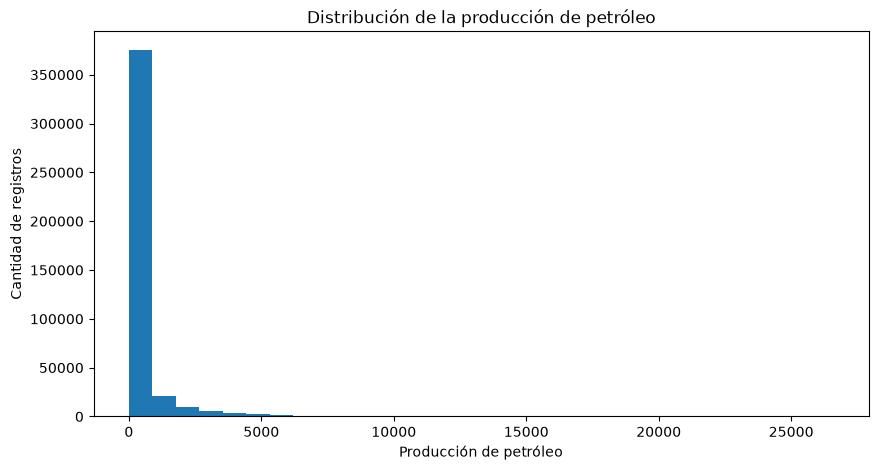

In [204]:
produccion["prod_pet"].plot(
    kind="hist",
    bins=30,
    figsize=(10, 5),
    title="Distribución de la producción de petróleo"
)

plt.xlabel("Producción de petróleo")
plt.ylabel("Cantidad de registros")
plt.show()

El histograma completo permite observar la cola de la distribución, pero los valores más altos dificultan visualizar con detalle la zona donde se concentra la mayoría de los registros.

Para complementar el análisis, realizamos una segunda visualización considerando los registros hasta el percentil 99 de `prod_pet`. De esta manera podemos observar con mayor detalle el comportamiento de la gran mayoría de los registros sin eliminar estos valores del dataset original.

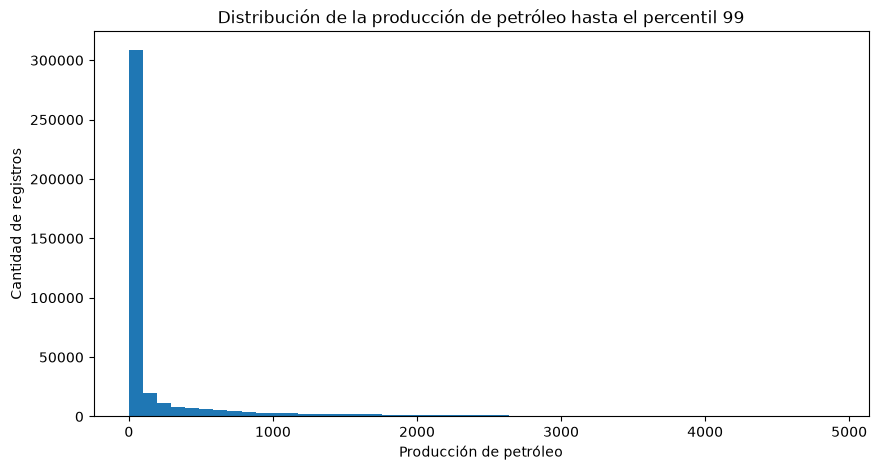

In [205]:
limite_p99 = produccion["prod_pet"].quantile(0.99)

produccion[produccion["prod_pet"] <= limite_p99]["prod_pet"].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5),
    title="Distribución de la producción de petróleo hasta el percentil 99"
)

plt.xlabel("Producción de petróleo")
plt.ylabel("Cantidad de registros")
plt.show()

La segunda visualización permite observar con mayor detalle la distribución de los valores que se encuentran dentro del 99% de los registros.

Se mantiene una concentración importante de observaciones en los valores bajos de producción y una disminución progresiva de la cantidad de registros a medida que aumenta la producción. Incluso al excluir de la visualización el 1% de los valores más altos, la distribución continúa presentando una marcada asimetría hacia la derecha.

Esto coincide con lo observado mediante los percentiles en la sección 3.3.2: mientras que el 75% de los registros tiene una producción de hasta 122,29, el 99% alcanza hasta 4.891,14. Por lo tanto, los valores elevados representan una proporción reducida del conjunto, pero generan una cola extensa en la distribución.

Los histogramas anteriores muestran que `prod_pet` presenta una distribución con una cola extensa hacia la derecha. En el histograma completo, la gran cantidad de registros con valores bajos hace que los rangos con valores elevados prácticamente no se distingan.

Para observar la distribución completa sin excluir registros, repetimos el histograma utilizando una escala logarítmica en el eje vertical.

En una escala logarítmica, cada marca del eje representa una cantidad diez veces mayor que la anterior (1, 10, 100, 1.000, ...). De esta manera podemos visualizar en un mismo gráfico tanto los rangos que contienen cientos de miles de registros como aquellos que contienen solo unos pocos.

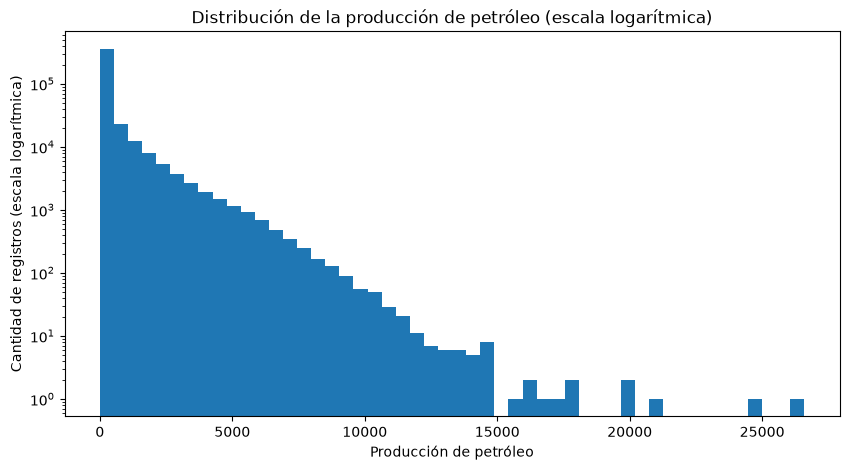

In [206]:
produccion["prod_pet"].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5),
    title="Distribución de la producción de petróleo (escala logarítmica)"
)

plt.yscale("log")
plt.xlabel("Producción de petróleo")
plt.ylabel("Cantidad de registros (escala logarítmica)")
plt.show()

El histograma en escala logarítmica permite observar la distribución completa de `prod_pet`, incluyendo los rangos de valores elevados que en el histograma original no se distinguían.

Se observa que la cantidad de registros disminuye de manera progresiva a medida que aumenta la producción, hasta valores cercanos a 15.000. A partir de ese punto aparecen solo unos pocos registros aislados, que llegan hasta el valor máximo de 26.593,26.

Estos registros con producción muy elevada deberán analizarse posteriormente como posibles valores atípicos (outliers), para determinar si corresponden a producciones reales o a errores de carga.

#### 6.2. Producción de gas

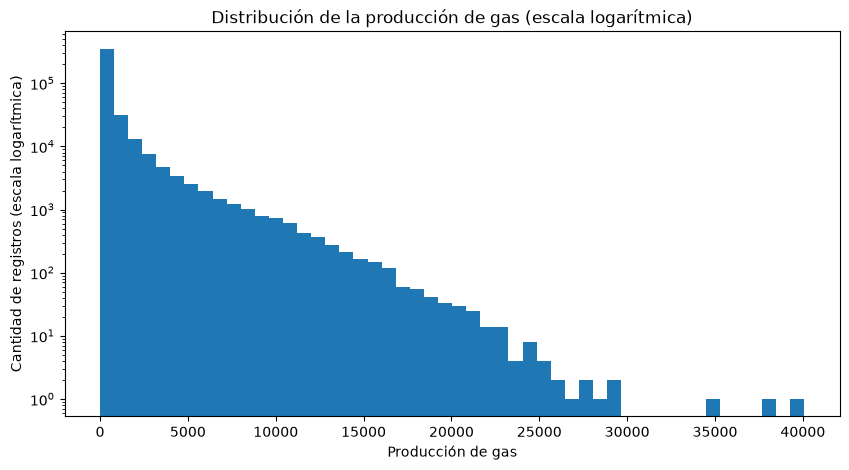

In [207]:
produccion_limpio["prod_gas"].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5),
    title="Distribución de la producción de gas (escala logarítmica)"
)

plt.yscale("log")
plt.xlabel("Producción de gas")
plt.ylabel("Cantidad de registros (escala logarítmica)")
plt.show()

La producción de gas tiene una forma muy parecida a la del petróleo: la mayoría de los registros se concentra en valores bajos y la cantidad disminuye de forma pareja a medida que la producción aumenta. Por encima de 30.000 solo quedan unos pocos registros aislados.

#### 6.3. Producción de agua

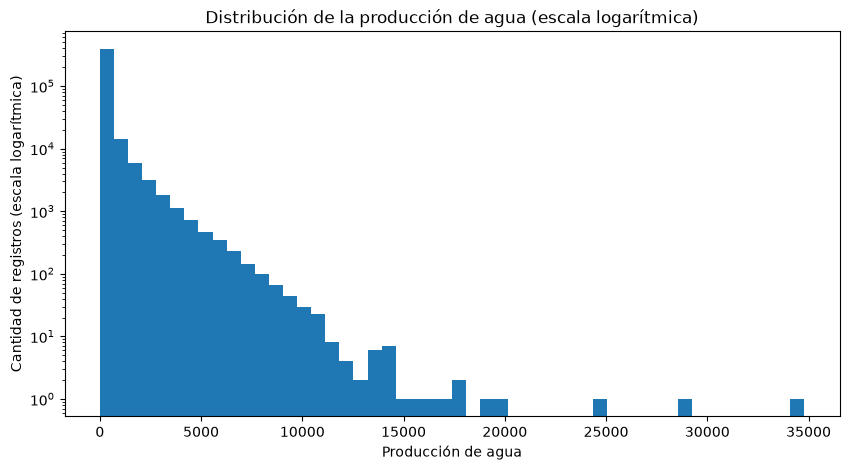

In [208]:
produccion_limpio["prod_agua"].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5),
    title="Distribución de la producción de agua (escala logarítmica)"
)

plt.yscale("log")
plt.xlabel("Producción de agua")
plt.ylabel("Cantidad de registros (escala logarítmica)")
plt.show()

Con la producción de agua pasa lo mismo: muchos registros con valores bajos y una cola larga hacia la derecha. En este caso la cantidad de registros baja más rápido, y por encima de 15.000 los registros ya son muy pocos.

#### 6.4. Días efectivos de producción (`tef`)

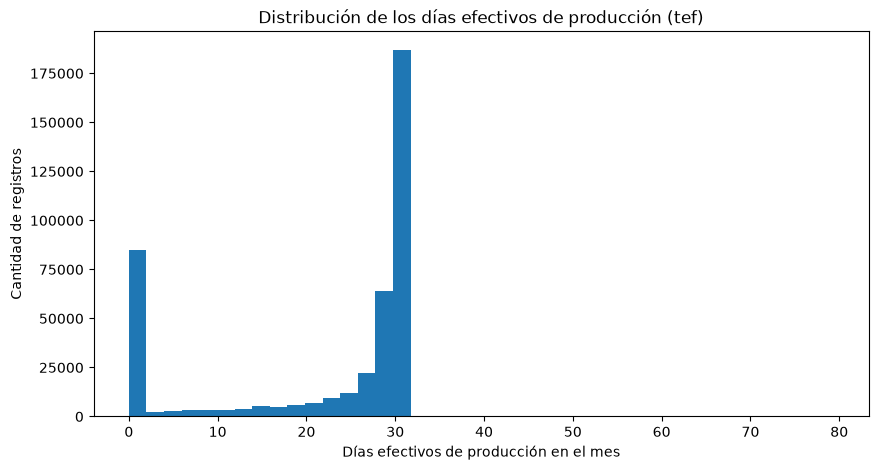

In [209]:
produccion_limpio["tef"].plot(
    kind="hist",
    bins=40,
    figsize=(10, 5),
    title="Distribución de los días efectivos de producción (tef)"
)

plt.xlabel("Días efectivos de producción en el mes")
plt.ylabel("Cantidad de registros")
plt.show()

Este histograma muestra dos grupos muy marcados:

- una gran cantidad de registros con 0 días, que son los meses en que el pozo no produjo;
- la mayor concentración entre 28 y 31 días, que son los meses en que el pozo produjo prácticamente todo el mes.

Entre esos dos extremos hay menos registros, que corresponden a meses en los que el pozo estuvo parado algunos días. A la derecha casi no se ven los 15 registros con más de 31 días que encontramos en la sección 5.1.

Esta variable puede ser útil más adelante, ya que la producción de un mes depende en gran parte de cuántos días estuvo activo el pozo.

#### 6.5. Profundidad de los pozos

Para analizar la profundidad usamos el dataset de pozos, donde cada pozo aparece una sola vez. Si usáramos el de producción, los pozos con muchos meses de historia pesarían más en el gráfico.

Filtramos los pozos no convencionales y dejamos afuera las profundidades de 0 y mayores a 10.000 metros que identificamos en la sección 5.

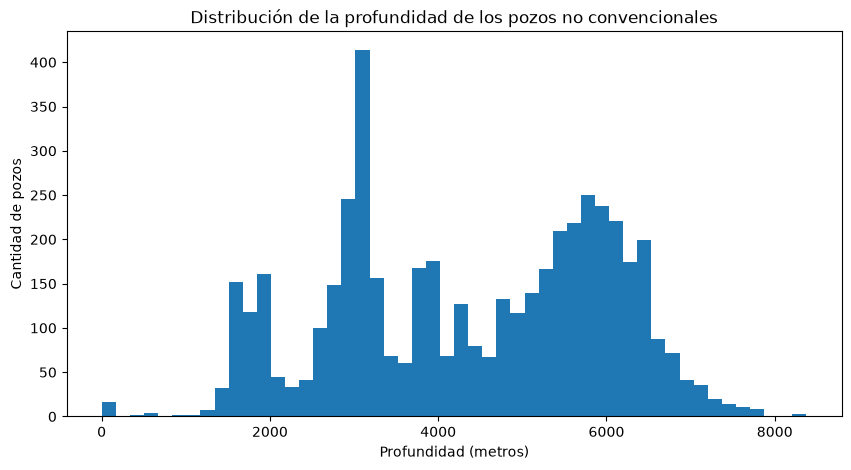

In [210]:
pozos_no_convencionales = pozos_limpio[pozos_limpio["tipo_recurso"] == "NO CONVENCIONAL"]

pozos_no_convencionales[
    (pozos_no_convencionales["profundidad"] > 0) & (pozos_no_convencionales["profundidad"] <= 10000)
]["profundidad"].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5),
    title="Distribución de la profundidad de los pozos no convencionales"
)

plt.xlabel("Profundidad (metros)")
plt.ylabel("Cantidad de pozos")
plt.show()

La profundidad no se concentra alrededor de un único valor, sino que muestra varios grupos: uno cerca de los 1.500 a 2.000 metros, otro muy marcado cerca de los 3.000 metros y un grupo amplio entre los 5.000 y 6.500 metros.

Estos grupos podrían corresponder a distintas formaciones o tipos de pozo, algo que puede ser interesante revisar más adelante en la etapa de clustering.

#### 6.6. Longitud de la rama horizontal

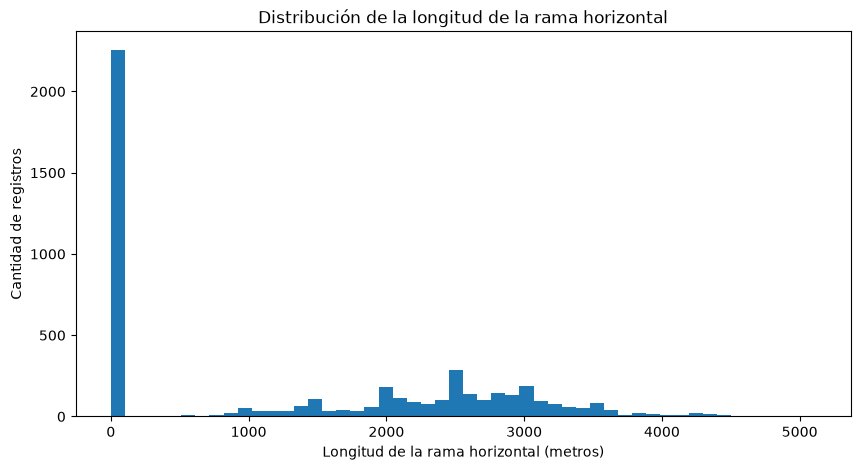

In [211]:
fracturacion_limpio["longitud_rama_horizontal_m"].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5),
    title="Distribución de la longitud de la rama horizontal"
)

plt.xlabel("Longitud de la rama horizontal (metros)")
plt.ylabel("Cantidad de registros")
plt.show()

El histograma muestra claramente dos tipos de pozos. Por un lado, una barra muy alta en 0, que corresponde a los pozos verticales. Por otro, los pozos horizontales, con ramas que en su mayoría van de 1.000 a 4.000 metros y se concentran cerca de los 2.500 metros.

#### 6.7. Cantidad de fracturas

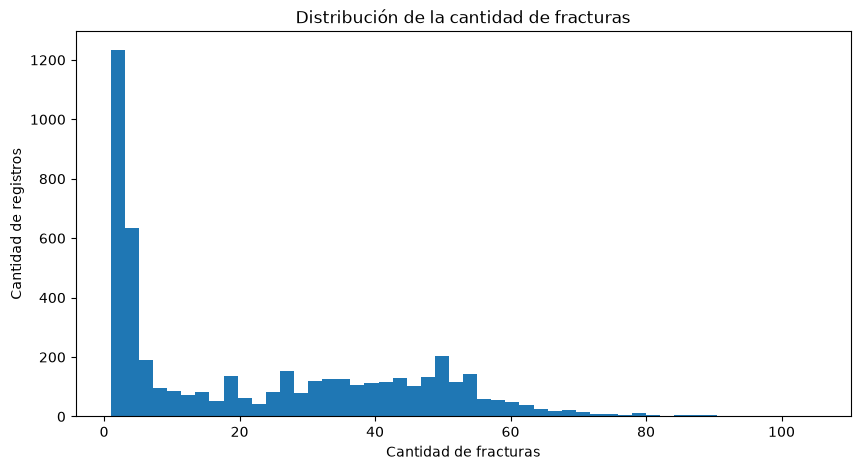

In [212]:
fracturacion_limpio["cantidad_fracturas"].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5),
    title="Distribución de la cantidad de fracturas"
)

plt.xlabel("Cantidad de fracturas")
plt.ylabel("Cantidad de registros")
plt.show()

La cantidad de fracturas también muestra la diferencia entre pozos verticales y horizontales. Un grupo grande de registros (cerca del 38%) tiene muy pocas fracturas, entre 1 y 5, lo que coincide con los pozos verticales. El resto se distribuye de forma bastante pareja entre 20 y 60 fracturas, con algunos casos que superan las 80.

#### 6.8. Agua inyectada en la fracturación

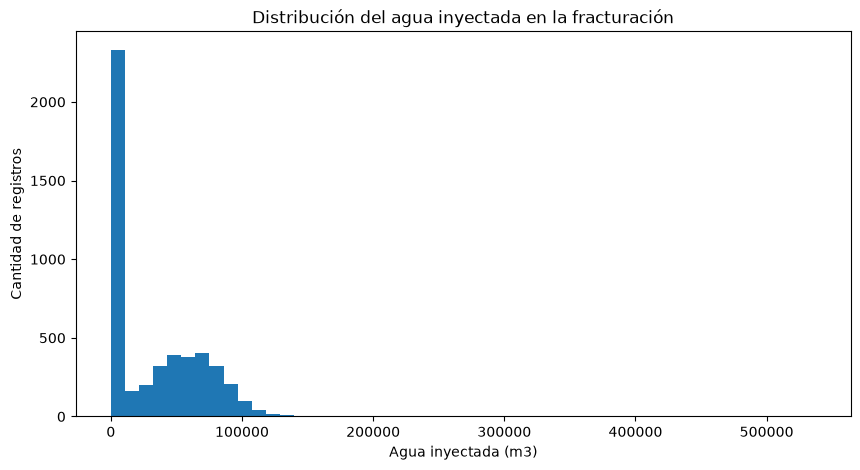

In [213]:
fracturacion_limpio["agua_inyectada_m3"].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5),
    title="Distribución del agua inyectada en la fracturación"
)

plt.xlabel("Agua inyectada (m3)")
plt.ylabel("Cantidad de registros")
plt.show()

El agua inyectada repite el mismo patrón: un grupo grande con valores cercanos a 0 y otro grupo que se concentra entre 30.000 y 100.000 m3. Muy pocos registros superan los 150.000 m3, y el máximo (más de 537.000 m3) queda muy alejado del resto.

#### 6.9. Conclusiones de los histogramas

- La producción de gas y de agua tiene la misma forma que la de petróleo: muchos registros con valores bajos y una cola larga de valores altos.
- La variable `tef` muestra que, en la mayoría de los meses, los pozos producen todo el mes o directamente no producen.
- La profundidad de los pozos no convencionales se agrupa en varios rangos distintos.
- En fracturación se distinguen claramente dos tipos de pozos: los verticales, sin rama horizontal y con pocas fracturas, y los horizontales, con ramas largas, muchas fracturas y más agua inyectada.

### 7. Comparaciones

Hasta ahora analizamos cada variable por separado. En esta sección comparamos algunas variables entre sí para entender mejor de qué depende la producción de petróleo.

#### 7.1. Producción de petróleo según el tipo de pozo

En la sección 3.3.1 vimos que el 35% de los registros no tiene producción de petróleo. Una posible explicación es que el dataset incluye pozos de gas, que no necesariamente producen petróleo.

Para comprobarlo, agrupamos los registros por `tipopozo` y calculamos la mediana de producción y el porcentaje de registros con producción de petróleo.

In [214]:
produccion_por_tipo_pozo = (
    produccion_limpio
    .groupby("tipopozo")
    .agg(
        cantidad_registros=("prod_pet", "count"),
        mediana_prod_pet=("prod_pet", "median"),
        registros_con_produccion=("prod_pet", lambda x: (x > 0).sum())
    )
)

produccion_por_tipo_pozo["porcentaje_con_produccion"] = (
    produccion_por_tipo_pozo["registros_con_produccion"]
    / produccion_por_tipo_pozo["cantidad_registros"]
    * 100
)

produccion_por_tipo_pozo = produccion_por_tipo_pozo.sort_values(
    "cantidad_registros",
    ascending=False
)

display(produccion_por_tipo_pozo)

,cantidad_registros,mediana_prod_pet,registros_con_produccion,porcentaje_con_produccion
tipopozo,,,,
Gasífero,228004,1.08,132210,57.985825
Petrolífero,163322,148.20,140432,85.984742
Otro tipo,28287,0.00,24,0.084845
Sumidero,712,0.00,1,0.140449
Inyección de Agua,56,0.00,0,0.000000
Inyección de Gas,50,0.00,17,34.000000
Acuífero,1,3384.97,1,100.000000


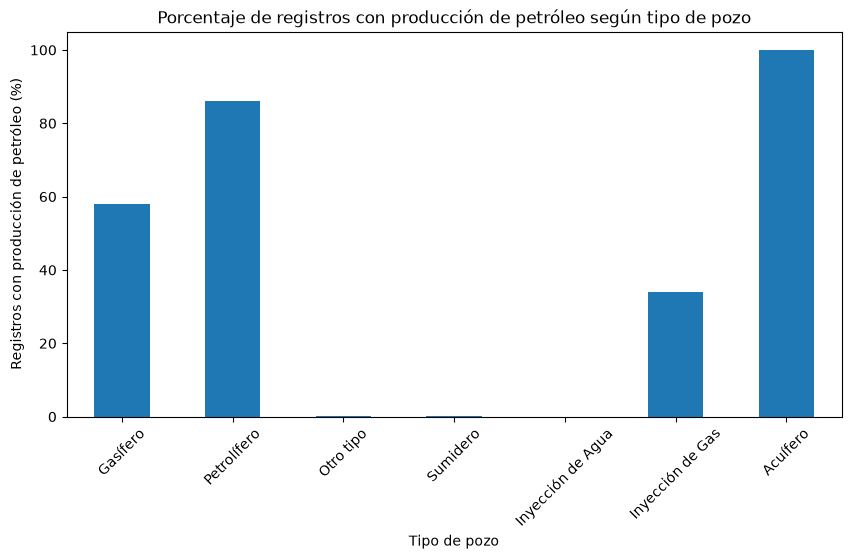

In [215]:
produccion_por_tipo_pozo["porcentaje_con_produccion"].plot(
    kind="bar",
    figsize=(10, 5),
    title="Porcentaje de registros con producción de petróleo según tipo de pozo"
)

plt.xlabel("Tipo de pozo")
plt.ylabel("Registros con producción de petróleo (%)")
plt.xticks(rotation=45)
plt.show()

Los resultados confirman la sospecha. Más de la mitad de los registros del dataset corresponden a pozos gasíferos (228.004), y en ellos la mediana de producción de petróleo es de apenas 1,08. En cambio, los pozos petrolíferos tienen una mediana de 148,20 y el 86% de sus registros tiene producción de petróleo.

Los pozos de tipo "Otro tipo", sumideros y de inyección casi no producen petróleo. El caso de "Acuífero" aparece con el 100%, pero corresponde a un único registro, así que no es representativo.

Esto es importante para el objetivo del proyecto: si queremos predecir la producción de petróleo, vamos a tener que decidir si incluimos todos los tipos de pozo o si nos concentramos en los petrolíferos.

#### 7.2. Evolución de la producción a lo largo de los años

Ahora analizamos cómo cambió la producción total de petróleo a lo largo del tiempo, sumando la producción de todos los pozos para cada año.

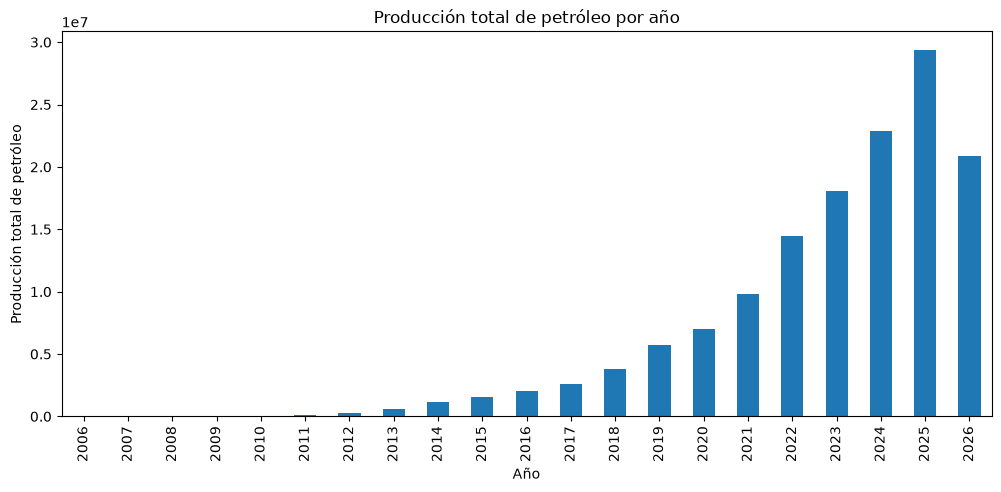

In [216]:
produccion_anual = produccion_limpio.groupby("anio")["prod_pet"].sum()

produccion_anual.plot(
    kind="bar",
    figsize=(12, 5),
    title="Producción total de petróleo por año"
)

plt.xlabel("Año")
plt.ylabel("Producción total de petróleo")
plt.show()

La producción total de petróleo creció de forma sostenida, sobre todo a partir de 2014. En 2025 fue unas 19 veces mayor que en 2015.

Hay que tener en cuenta que 2026 solo tiene datos de enero a julio. Por eso su barra es más baja que la de 2025, aunque con 7 meses ya supera la producción de todo 2023.

Para saber si este crecimiento se debe a que hay más pozos produciendo, contamos cuántos pozos distintos tuvieron producción de petróleo cada año.

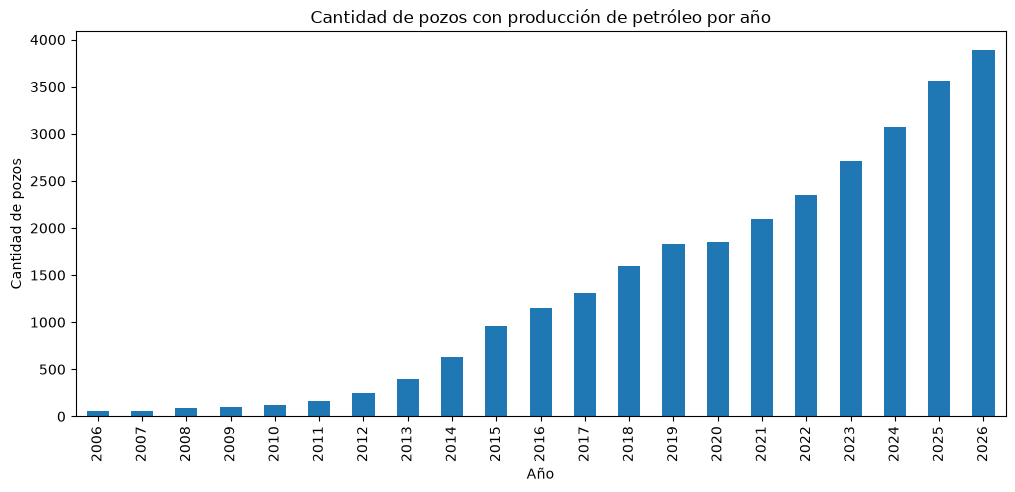

In [217]:
pozos_con_produccion_por_anio = (
    produccion_limpio[produccion_limpio["prod_pet"] > 0]
    .groupby("anio")["idpozo"]
    .nunique()
)

pozos_con_produccion_por_anio.plot(
    kind="bar",
    figsize=(12, 5),
    title="Cantidad de pozos con producción de petróleo por año"
)

plt.xlabel("Año")
plt.ylabel("Cantidad de pozos")
plt.show()

La cantidad de pozos con producción de petróleo también creció año a año: pasó de 52 pozos en 2006 a 960 en 2015 y a 3.564 en 2025. En 2026, con solo 7 meses, ya hay 3.893 pozos con producción.

Comparando los dos gráficos, vemos que la producción total creció más rápido que la cantidad de pozos. Esto indica que, además de haber más pozos, en promedio cada pozo produce más que antes.

#### 7.3. Producción de petróleo por formación

En las secciones 3.2 y 3.6 vimos que Vaca Muerta es la formación con más registros y analizamos la mediana y la frecuencia de producción de cada formación. Aquí miramos otro aspecto: calculamos qué porcentaje de la producción total de petróleo aporta cada formación.

In [218]:
produccion_total_por_formacion = (
    produccion_limpio
    .groupby("formacion")["prod_pet"]
    .sum()
    .sort_values(ascending=False)
)

porcentaje_por_formacion = produccion_total_por_formacion / produccion_total_por_formacion.sum() * 100

display(porcentaje_por_formacion.head(5))

formacion
VACA MUERTA     96.434721
LAJAS            1.834585
PUNTA ROSADA     0.646272
MULICHINCO       0.294375
MAGALLANES       0.215409
Name: prod_pet, dtype: float64

Vaca Muerta concentra el 96,4% de toda la producción de petróleo del dataset, a pesar de tener solo alrededor de la mitad de los registros. La segunda formación, Lajas, aporta menos del 2%.

Esto muestra que el comportamiento del dataset está dominado casi por completo por los pozos de Vaca Muerta.

#### 7.4. Evolución de la fracturación

En las secciones 6.6 y 6.7 vimos que los pozos horizontales tienen ramas mucho más largas y más fracturas que los verticales. Ahora analizamos cómo cambiaron estas características con los años.

Para esto nos quedamos solo con los pozos horizontales (con longitud de rama mayor a 0) y calculamos, para cada año, la mediana de la longitud de la rama y de la cantidad de fracturas.

In [219]:
fracturas_horizontales = fracturacion_limpio[fracturacion_limpio["longitud_rama_horizontal_m"] > 0]

evolucion_fracturas = fracturas_horizontales.groupby("anio").agg(
    cantidad_registros=("idpozo", "count"),
    mediana_rama_horizontal=("longitud_rama_horizontal_m", "median"),
    mediana_fracturas=("cantidad_fracturas", "median")
)

display(evolucion_fracturas)

,cantidad_registros,mediana_rama_horizontal,mediana_fracturas
anio,,,
2009,2,945.00,5.5
2010,8,1000.00,5.0
2011,21,71.00,1.0
2012,13,180.00,4.0
2013,26,388.50,4.0
2014,28,1007.00,9.5
2015,51,1201.00,15.0
2016,117,1408.90,18.0
2017,153,1575.30,20.0


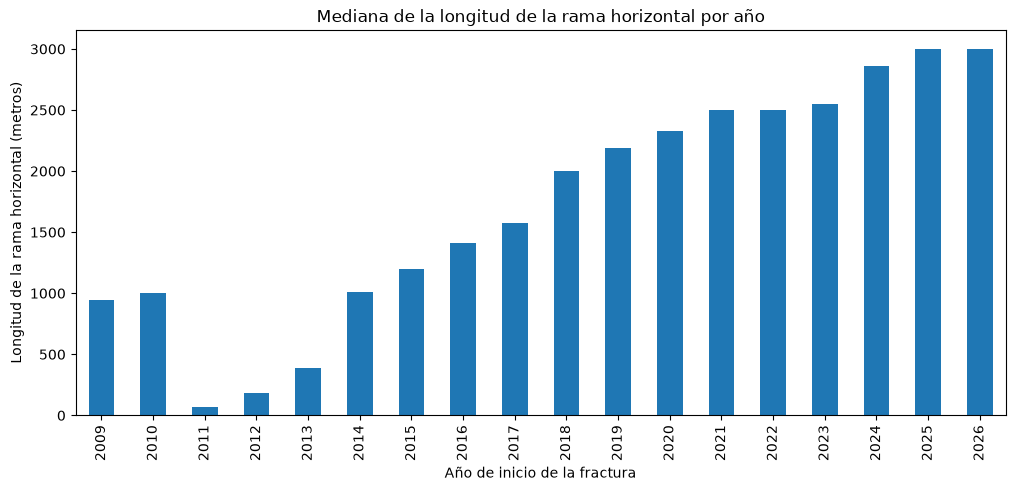

In [220]:
evolucion_fracturas["mediana_rama_horizontal"].plot(
    kind="bar",
    figsize=(12, 5),
    title="Mediana de la longitud de la rama horizontal por año"
)

plt.xlabel("Año de inicio de la fractura")
plt.ylabel("Longitud de la rama horizontal (metros)")
plt.show()

La longitud de la rama horizontal aumentó de forma constante: la mediana pasó de unos 1.000 metros en 2014 a unos 3.000 metros en 2025 y 2026. La cantidad de fracturas acompañó ese crecimiento, pasando de una mediana de 9,5 en 2014 a 50 en 2025.

Los valores de 2009 a 2013 son más irregulares porque hay muy pocos registros por año (entre 2 y 26), así que no son tan representativos.

Esto coincide con lo que vimos en la sección 7.2: los pozos más nuevos tienen ramas más largas y más fracturas, lo que podría explicar por qué producen más.

Para ver la relación entre la longitud de la rama y la cantidad de fracturas, usamos un gráfico de dispersión, donde cada punto es un registro de fracturación.

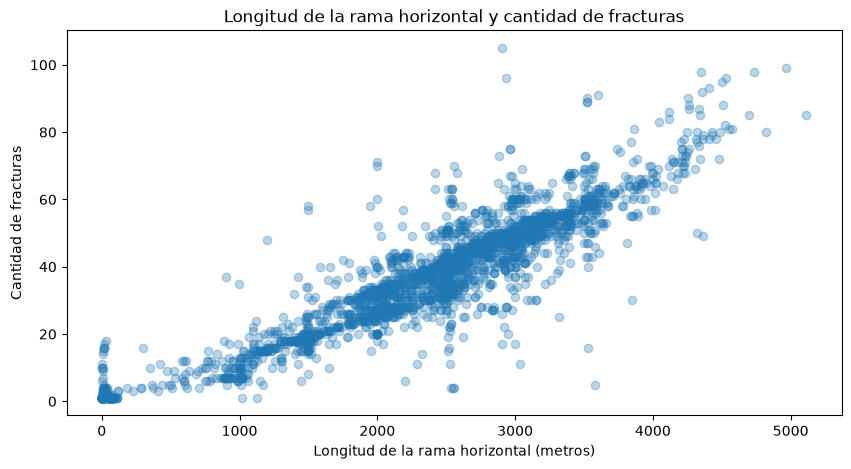

In [221]:
plt.figure(figsize=(10, 5))

plt.scatter(
    fracturas_horizontales["longitud_rama_horizontal_m"],
    fracturas_horizontales["cantidad_fracturas"],
    alpha=0.3
)

plt.title("Longitud de la rama horizontal y cantidad de fracturas")
plt.xlabel("Longitud de la rama horizontal (metros)")
plt.ylabel("Cantidad de fracturas")
plt.show()

El gráfico muestra una relación clara: cuanto más larga es la rama horizontal, más fracturas tiene el pozo. Los puntos forman una franja que sube de izquierda a derecha, con pocos casos alejados.

Tiene sentido, porque las fracturas se hacen a lo largo de la rama. Para los modelos esto significa que ambas variables aportan información parecida, algo que habrá que tener en cuenta al elegir las variables.

#### 7.5. Comparación de métodos para detectar outliers en `prod_pet`

En la sección 6 vimos que la producción tiene una cola larga de valores altos. Para saber cuántos de esos valores se consideran atípicos, comparamos los dos métodos habituales: el rango intercuartílico (RIC) y el z-score.

Con el RIC, un valor es atípico si está por debajo de Q1 - 1,5 × RIC o por encima de Q3 + 1,5 × RIC.

In [222]:
q1 = produccion_limpio["prod_pet"].quantile(0.25)
q3 = produccion_limpio["prod_pet"].quantile(0.75)
ric = q3 - q1

limite_inferior = q1 - 1.5 * ric
limite_superior = q3 + 1.5 * ric

outliers_ric = produccion_limpio[
    (produccion_limpio["prod_pet"] < limite_inferior) | (produccion_limpio["prod_pet"] > limite_superior)
]

print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)
print("Outliers según RIC:", len(outliers_ric))
print(f"Porcentaje de outliers según RIC: {len(outliers_ric) / len(produccion_limpio) * 100:.2f}%")

Límite inferior: -183.4375875
Límite superior: 305.7293125
Outliers según RIC: 79924
Porcentaje de outliers según RIC: 18.98%


Con el z-score, un valor es atípico si se aleja más de 3 desvíos estándar de la media.

In [223]:
media_prod_pet = produccion_limpio["prod_pet"].mean()
desvio_prod_pet = produccion_limpio["prod_pet"].std()

z_score = (produccion_limpio["prod_pet"] - media_prod_pet) / desvio_prod_pet

outliers_z = produccion_limpio[(z_score > 3) | (z_score < -3)]

print("Valor de producción equivalente a z-score = 3:", media_prod_pet + 3 * desvio_prod_pet)
print("Outliers según z-score:", len(outliers_z))
print(f"Porcentaje de outliers según z-score: {len(outliers_z) / len(produccion_limpio) * 100:.2f}%")

Valor de producción equivalente a z-score = 3: 3147.5651256849214
Outliers según z-score: 10782
Porcentaje de outliers según z-score: 2.56%


Los dos métodos dan resultados muy distintos:

- el RIC marca como atípicos todos los registros con producción mayor a 305,73, lo que representa casi el 19% del dataset;
- el z-score solo marca los registros con producción mayor a 3.147,57, que son el 2,56%.

La diferencia se explica por la forma de la distribución. Como la mayoría de los registros tiene producción baja o igual a 0, el RIC queda muy chico y cualquier producción moderada ya aparece como atípica.

El diagrama de caja muestra claramente esta situación: la caja queda aplastada cerca de 0 y todos los valores altos aparecen como puntos sueltos por encima.

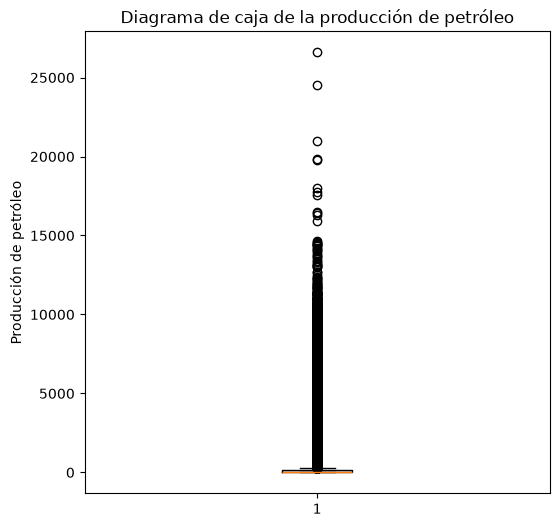

In [224]:
plt.figure(figsize=(6, 6))

plt.boxplot(produccion_limpio["prod_pet"])

plt.title("Diagrama de caja de la producción de petróleo")
plt.ylabel("Producción de petróleo")
plt.show()

Para entender a qué pozos corresponden los valores atípicos, vemos su tipo de pozo y su formación.

In [225]:
print("Outliers según z-score por tipo de pozo:")
display(outliers_z["tipopozo"].value_counts())

print("Outliers según z-score por formación:")
display(outliers_z["formacion"].value_counts())

Outliers según z-score por tipo de pozo:


tipopozo
Petrolífero    10390
Gasífero         391
Acuífero           1
Name: count, dtype: int64

Outliers según z-score por formación:


formacion
VACA MUERTA    10780
QUINTUCO           1
LAJAS              1
Name: count, dtype: int64

Casi todos los valores atípicos según el z-score corresponden a pozos petrolíferos de Vaca Muerta, que son justamente los que más producen.

Por lo tanto, en este caso los valores atípicos no parecen errores, sino pozos con una producción real muy alta. Eliminarlos haría que perdamos los pozos más importantes del dataset. Por eso no los vamos a tratar como errores y los vamos a conservar para el análisis.

### 8. Conclusiones generales

A partir del formateo y la exploración de los datos llegamos a las siguientes conclusiones:

**Sobre la calidad de los datos**

- Convertimos todas las fechas a tipo fecha y las columnas de sí/no a booleanas, y unificamos la escritura de las formaciones.
- Identificamos columnas que no aportan información, ya sea porque tienen un único valor o porque repiten los datos de otra columna.
- Encontramos algunos valores imposibles (producciones negativas, más días efectivos que los que tiene el mes, profundidades de 0 o de 378.939 metros, fechas de 1900 o futuras, coordenadas invertidas). Son pocos en relación con el total y los vamos a tratar en la etapa de limpieza.

**Sobre el comportamiento de la producción**

- La producción de petróleo, gas y agua se concentra en valores bajos y tiene una cola larga de valores altos.
- Gran parte de los registros sin producción de petróleo corresponden a pozos gasíferos o de otros tipos. Los pozos petrolíferos producen petróleo en el 86% de sus registros.
- Vaca Muerta concentra el 96,4% de la producción total de petróleo.
- La producción creció fuertemente a lo largo de los años, más rápido que la cantidad de pozos.

**Sobre la fracturación**

- Hay dos grupos claros de pozos: verticales, con pocas fracturas, y horizontales, con ramas largas y muchas fracturas.
- Con los años, las ramas horizontales se hicieron más largas y la cantidad de fracturas aumentó, lo que podría explicar el aumento de producción por pozo.

**Alcance de este análisis**

Este análisis exploratorio es meramente informativo: su objetivo es conocer los datasets, su calidad y el comportamiento general de la producción a lo largo de toda la historia disponible.

Para el estudio y la proyección de los algoritmos de ciencia de datos, consideramos que deberían tomarse como máximo los registros de 2025 y 2026. Para dimensionar este período, calculamos cuántos registros, pozos y meses incluye y qué parte de la producción total de petróleo representa.

In [226]:
produccion_modelado = produccion_limpio[produccion_limpio["anio"] >= 2025]

print("Registros de 2025 y 2026:", len(produccion_modelado))
print(f"Porcentaje del total de registros: {len(produccion_modelado) / len(produccion_limpio) * 100:.1f}%")
print("Pozos distintos:", produccion_modelado["idpozo"].nunique())
print("Meses con datos:", produccion_modelado["fecha_data"].nunique())
print(f"Porcentaje de la producción total de petróleo: {produccion_modelado['prod_pet'].sum() / produccion_limpio['prod_pet'].sum() * 100:.1f}%")

Registros de 2025 y 2026: 88610
Porcentaje del total de registros: 21.0%
Pozos distintos: 5071
Meses con datos: 19
Porcentaje de la producción total de petróleo: 35.8%


Este período reúne 88.610 registros (el 21% del total), 5.071 pozos y 19 meses de datos, y concentra el 35,8% de la producción total de petróleo del dataset.

Por este motivo, los problemas de calidad detectados en registros anteriores a 2025, como las producciones negativas (de 2008 y 2020), tienen un impacto limitado en el modelado. Sin embargo, no todos quedan fuera de ese período: 34 de los 71 registros con más días efectivos que los del mes corresponden a 2025, en su mayoría por haber copiado los días del mes anterior, por lo que igualmente deberán tratarse en la etapa de limpieza.

**Próximos pasos**

- Filtrar los datos a los años 2025 y 2026 para el entrenamiento de los modelos.
- Decidir cómo tratar los valores imposibles que identificamos, en particular los que corresponden a ese período. Para `tef` proponemos truncarlo a los días del mes y marcar los registros corregidos (sección 5.1).
- No usar el `tef` del mes que se quiere predecir como variable del modelo, ya que ese dato no se conoce de antemano.
- Definir si el modelo se va a entrenar con todos los tipos de pozo o solo con los petrolíferos.
- Relacionar los datasets mediante `idpozo` para estudiar cómo influyen las características de los pozos y de la fracturación en la producción.